# QADD v4.1 — extrinsic additive acoustic interference

**Purpose.** Validate and extract a small, prespecified vector of recording-level
indicators of extrinsic additive acoustic interference from frozen speech and
internal-nonspeech intervals. This notebook does not validate segmentation and
does not construct a scalar QADD score.

The notebook is the reference structure for every feature family:

1. measurement contract and frozen parameters;
2. frozen-input/provenance contract;
3. deterministic formula and reconstruction tests;
4. mechanism-positive and discriminant-negative synthetic controls;
5. censoring/support calibration;
6. full extraction with reconstructable ledgers;
7. boundary, signal-view, and codec robustness;
8. empirical distributions, availability, and within-family structure;
9. publication figures and a reviewer-facing audit gallery;
10. separate technical, scientific, review, and integration gates.

### Prespecified analysis vector

| Feature | Role | Interpretation limit |
|---|---|---|
| `qadd_pause_ac_level_dbfs_median` | **Primary** | Analysis-view AC level, not dB SPL or native-stream dBFS |
| `qadd_pause_level_iqr_db` | Secondary | Temporal heterogeneity; not an ordinal burden scale |
| `qadd_speech_pause_level_contrast_db` | Mixed secondary | Not physical SNR; depends on speech production and gain |
| `qadd_pause_spectral_flatness` | Non-ordinal descriptor | Broadband-like vs tonal/structured; neither endpoint is universally worse |
| `qadd_mains_hum_comb_score_db` | Targeted descriptor | Study-specific engineering score, not a perceptual threshold |

Digital-floor fractions, exact-zero fractions, supports, feature statuses, and
native/analysis-view differences are audit evidence, not substitute biomarkers.
Upper-tail and 30-ms “transient” metrics from QADD v2 are excluded from the v4.1
confirmatory vector.

### v4.1 measurement-development correction

The v4.0 cohort run demonstrated that usable-signal duration alone cannot establish
robustness: several seconds of pause material can still contain strongly
heterogeneous pause intervals. v4.1 therefore uses the neutral support classes
`minimum`, `moderate`, and `high`; it reports whole-pause deletion sensitivity once
per recording for **all five features**. Large changes are retained because
nonstationary or rare interference is part of the QADD construct.

The 200-ms guard remains the fixed operational definition. A further 100-ms erosion
of the already-selected pause support is reported as construct/boundary sensitivity,
including feature availability. It is not mislabelled as repeatability and is not
forced through an arbitrary 1-dB acceptance threshold.

### Measurement basis

RMS/digital level and speech activity concepts follow
[ITU-T P.56](https://www.itu.int/rec/T-REC-P.56);
the additive-noise listening construct is consistent with the signal/noise/overall
separation in [ITU-T P.835](https://www.itu.int/rec/T-REC-P.835);
spectral flatness follows the established geometric-to-arithmetic power ratio
described by [Johnston (1988)](https://doi.org/10.1109/49.608);
harmonic prominence is an established engineering idea, while the exact robust
50/60-Hz comb estimator below is explicitly study-specific and must pass its own
false-positive controls.


## 0. Environment, run controls, and common output contract

The notebook imports the estimator from `paper1_qc.qadd`; no feature algorithm is
duplicated here. The default run is safe in a source-only checkout: deterministic
controls run, while cohort extraction is an explicit opt-in after the frozen-input
preflight succeeds. Publication/freeze remains opt-in.


In [1]:
from __future__ import annotations

from dataclasses import replace
from hashlib import sha256
from pathlib import Path
from tempfile import TemporaryDirectory
import json
import math
import shutil
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from IPython.display import Markdown, display
import yaml


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "paper1_qc").exists():
            return candidate
    raise FileNotFoundError("Open this notebook from inside the paper1 pipeline repository.")


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from paper1_qc.feature_validation import (
    OKABE_ITO,
    ValidationCheck,
    gate_passed,
    save_publication_figure,
    save_table_bundle,
    set_publication_style,
    sha256_file,
    validation_frame,
    write_json,
)
from paper1_qc.media import decode_audio_views
from paper1_qc.qadd import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    FEATURE_DEFINITIONS,
    MEASUREMENT_VERSION,
    PRIMARY_FEATURES,
    QADDParameters,
    TimeInterval,
    ac_rms_measurement,
    apply_hum_null_calibration,
    cluster_delete_one_diagnostics,
    compare_reconstruction,
    erode_intervals,
    extract_qadd,
    feature_registry_frame,
    guarded_internal_pauses,
    hum_comb_score_from_psd,
    intersect_intervals,
    power_spectrum,
    summarize_cluster_deletion,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
set_publication_style()

CONFIG = ROOT / "config" / "project.yaml"
MAIN_OUTPUTS = ROOT / "MAIN outputs"
STAGE = ROOT / "outputs" / "02_features" / "additive_interference" / MEASUREMENT_VERSION
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
GALLERY = STAGE / "gallery"
AUDIT = STAGE / "audit"
for directory in [TABLES, FIGURES, GALLERY, AUDIT]:
    directory.mkdir(parents=True, exist_ok=True)

# Explicit opt-in prevents a source checkout with a config file but no
# mounted frozen inputs from failing unexpectedly.
RUN_COHORT_EXTRACTION = True
RUN_CODEC_ROUNDTRIP = True
# Package tests are run from the shell before the notebook. Keep the
# optional in-notebook subprocess off to avoid duplicating a Python/
# SciPy process after memory-intensive cohort extraction.
RUN_PACKAGE_TESTS = True
PACKAGE_TESTS_CONFIRMED = True
BUILD_GALLERY = True
MAX_BOUNDARY_RECORDINGS = 60

PUBLISH_AND_FREEZE_QADD_V4_1 = False
PACKAGE_INTEGRATION_APPROVED = False
QADD_REVIEW_DECISION = "UNDECIDED"  # ACCEPT_QADD_V4_1 / REVISE
QADD_REVIEWER = ""
QADD_REVIEW_RATIONALE = ""

PARAMETERS = DEFAULT_PARAMETERS
RNG = np.random.default_rng(PARAMETERS.random_seed)

print("Project:", ROOT)
print("Measurement:", MEASUREMENT_VERSION)
print("Cohort extraction:", RUN_COHORT_EXTRACTION)
print("Outputs:", STAGE)


Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Measurement: qadd-v4.1.0
Cohort extraction: True
Outputs: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\additive_interference\qadd-v4.1.0


## 1. Measurement contract and feature registry

Every family notebook must state the estimand, unit, role, direction, establishment
status, known confounding, claim limit, support field, and status field before data
are examined. Roles do not imply that features form a reflective scale.


In [2]:
feature_registry = feature_registry_frame()
parameter_table = pd.DataFrame(
    [{"parameter": key, "value": json.dumps(value) if isinstance(value, (list, dict, tuple)) else value}
     for key, value in PARAMETERS.to_dict().items()]
)
crosswalk = pd.DataFrame(
    [
        {"v2_measure": "qadd_pause_level_dbfs_median", "v4_measure": "qadd_pause_ac_level_dbfs_median", "decision": "retained and renamed", "reason": "make AC-RMS and analysis-view scale explicit"},
        {"v2_measure": "qadd_pause_level_iqr_db", "v4_measure": "qadd_pause_level_iqr_db", "decision": "retained secondary", "reason": "robust temporal heterogeneity descriptor"},
        {"v2_measure": "qadd_speech_pause_contrast_db", "v4_measure": "qadd_speech_pause_level_contrast_db", "decision": "retained and renamed", "reason": "avoid physical-SNR interpretation"},
        {"v2_measure": "qadd_pause_spectral_flatness", "v4_measure": "qadd_pause_spectral_flatness", "decision": "retained non-ordinal", "reason": "established spectral-type descriptor"},
        {"v2_measure": "qadd_hum_prominence_db_raw", "v4_measure": "qadd_mains_hum_comb_score_db", "decision": "redesigned targeted", "reason": "robust local harmonic evidence with explicit false-positive validation"},
        {"v2_measure": "qadd_pause_upper_tail_db", "v4_measure": None, "decision": "removed", "reason": "redundant/unstable upper-tail construct"},
        {"v2_measure": "qadd_transient_rate_per_min", "v4_measure": None, "decision": "removed", "reason": "30-ms energy excursions were not a validated click/transient construct"},
    ]
)
save_table_bundle(feature_registry, TABLES, "qadd_v4_1_feature_registry")
save_table_bundle(parameter_table, TABLES, "qadd_v4_1_parameters")
save_table_bundle(crosswalk, TABLES, "qadd_v2_to_v4_crosswalk")
write_json(PARAMETERS.to_dict(), AUDIT / "qadd_v4_1_parameters.json")
display(feature_registry)
display(crosswalk)


,measurement_version,feature,display_name,role,unit,direction,estimator,construct,establishment,claim_limit,signal_region,support_field,status_field,mathematical_range,positive_control,discriminant_control,known_confounding,signal_view,missing_value_behavior,analysis_eligible,composite_use_prohibited
0,qadd-v4.1.0,qadd_pause_ac_level_dbfs_median,Guarded-pause AC level (median),primary,analysis-view dBFS,higher means more recorded non-floor pause energy,median 30-ms AC-RMS frame level; 10-ms hop,recorded pause energy consistent with extrinsi...,RMS/dBFS are established; the guarded-pause ap...,"not dB SPL, native-stream dBFS, environmental ...",guarded internal strict-nonspeech,qadd_pause_level_support_tier,qadd_pause_ac_level_dbfs_median_status,"[-120, 0] dBFS for unclipped normalized PCM an...",unit-slope response to injected pause-noise level,independent of noise spectral color at matched...,"device gain, distance, room noise, channel pro...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True
1,qadd-v4.1.0,qadd_pause_level_iqr_db,Guarded-pause level IQR,secondary,dB,contextual; higher means greater within-record...,Q75 minus Q25 of eligible pause-frame AC levels,temporal heterogeneity of recorded pause energy,IQR is established robust dispersion; this app...,not an ordinal severity measure and sensitive ...,guarded internal strict-nonspeech,qadd_pause_dispersion_support_tier,qadd_pause_level_iqr_db_status,"[0, +infinity) dB",increases under amplitude-modulated or changin...,invariant to global gain,"number/distribution of pauses, transient resid...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True
2,qadd-v4.1.0,qadd_speech_pause_level_contrast_db,Speech-pause level contrast,mixed_secondary,dB,lower means less within-recording level separa...,median strict-speech AC level minus median gua...,within-recording speech-to-pause level separation,level contrast is established; interpretation ...,not physical SNR; also depends on speech inten...,strict speech and guarded internal strict-nons...,qadd_speech_pause_contrast_support_tier,qadd_speech_pause_level_contrast_db_status,unbounded difference in dB,decreases as injected pause-noise level rises,invariant to global gain,"speech intensity, bulbar impairment, microphon...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True
3,qadd-v4.1.0,qadd_pause_spectral_flatness,Guarded-pause spectral flatness,secondary_descriptor,ratio,non-ordinal; high is broadband-like and low is...,median power-spectrum flatness from 80-7000 Hz...,spectral type of recorded pause interference,spectral flatness is established; the band/agg...,neither endpoint is universally worse; channel...,non-floor guarded internal strict-nonspeech wi...,qadd_flatness_support_tier,qadd_pause_spectral_flatness_status,"(0, 1]",higher for broadband noise than tonal interfer...,invariant to global gain; low for off-grid tones,"channel bandwidth, codec filtering, spectral c...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True
4,qadd-v4.1.0,qadd_mains_hum_comb_score_db,50/60-Hz mains-hum comb score,targeted_descriptor,dB,higher means stronger 50/60-Hz harmonic structure,max 50/60-Hz median local contrast across harm...,mains-frequency harmonic interference in recor...,harmonic prominence is established; this exact...,not a perceptual threshold; requires off-grid ...,non-floor guarded internal strict-nonspeech wi...,qadd_hum_support_tier,qadd_mains_hum_comb_score_db_status,unbounded local power contrast in dB,increases for 50/60-Hz harmonic combs,colored-noise and 53-Hz off-grid nulls,"frequency drift, narrowband machinery, spectra...","mono, DC-removed, resampled 16-kHz analysis view",analysis value is NaN unless feature status be...,True,True


,v2_measure,v4_measure,decision,reason
0,qadd_pause_level_dbfs_median,qadd_pause_ac_level_dbfs_median,retained and renamed,make AC-RMS and analysis-view scale explicit
1,qadd_pause_level_iqr_db,qadd_pause_level_iqr_db,retained secondary,robust temporal heterogeneity descriptor
2,qadd_speech_pause_contrast_db,qadd_speech_pause_level_contrast_db,retained and renamed,avoid physical-SNR interpretation
3,qadd_pause_spectral_flatness,qadd_pause_spectral_flatness,retained non-ordinal,established spectral-type descriptor
4,qadd_hum_prominence_db_raw,qadd_mains_hum_comb_score_db,redesigned targeted,robust local harmonic evidence with explicit f...
5,qadd_pause_upper_tail_db,None,removed,redundant/unstable upper-tail construct
6,qadd_transient_rate_per_min,None,removed,30-ms energy excursions were not a validated c...


## 2. Frozen input and provenance contract

Segmentation is accepted as frozen upstream evidence. QADD may test estimator
sensitivity to interval boundaries, but it never changes the segmentation freeze.
Eligible-recording identity, selected media path, and exact interval-table identity
are recorded before extraction.


In [3]:
def _table_file(stem: Path) -> Path:
    if stem.suffix.lower() in {".csv", ".parquet"} and stem.exists():
        return stem
    for suffix in [".parquet", ".csv"]:
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Missing table: {stem}")


def read_table(stem: Path) -> pd.DataFrame:
    path = _table_file(stem)
    return pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)


def as_bool(series: pd.Series) -> pd.Series:
    return series.map(lambda value: value if isinstance(value, bool) else str(value).strip().lower() in {"1", "true", "yes", "y"})


def discover_interval_table(folder: Path) -> tuple[Path, pd.DataFrame]:
    candidates = []
    seen = set()
    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in {".csv", ".parquet"}:
            continue
        stem = path.with_suffix("")
        if stem in seen and path.suffix.lower() == ".csv":
            continue
        seen.add(stem)
        try:
            frame = read_table(path)
        except Exception:
            continue
        columns = set(frame.columns)
        if not ({"start_sec", "end_sec"}.issubset(columns) or {"start", "end"}.issubset(columns)):
            continue
        if not {"view", "segment_type", "label", "region"}.intersection(columns):
            continue
        if not {"logical_recording_id", "file_name"}.intersection(columns):
            continue
        score = 8 * ("frozen" in path.stem.lower()) + 6 * ("interval" in path.stem.lower()) + 2 * (path.suffix.lower() == ".parquet")
        candidates.append((score, path, frame))
    if not candidates:
        raise FileNotFoundError(f"No unambiguous frozen interval table under {folder}")
    candidates.sort(key=lambda item: (-item[0], str(item[1])))
    if len(candidates) > 1 and candidates[0][0] == candidates[1][0]:
        raise RuntimeError("Tied interval-table candidates; resolve explicitly before extraction.")
    return candidates[0][1], candidates[0][2]


def load_frozen_inputs() -> dict:
    cfg = yaml.safe_load(CONFIG.read_text(encoding="utf-8"))
    segmentation_version = str(cfg.get("segmentation_freeze", {}).get("version", cfg.get("data_freeze", {}).get("version", "v1")))
    data_version = str(cfg.get("data_freeze", {}).get("version", "v1"))
    segmentation_folder = MAIN_OUTPUTS / "01_SEGMENTATION_FREEZE" / segmentation_version
    data_folder = MAIN_OUTPUTS / "00_DATA_FREEZE" / data_version
    decisions_path = _table_file(segmentation_folder / "frozen_segmentation_decisions")
    recordings_path = _table_file(data_folder / "frozen_bamboo_recordings")
    intervals_path, intervals = discover_interval_table(segmentation_folder)
    decisions = read_table(decisions_path)
    recordings = read_table(recordings_path)

    if "segmentation_analysis_eligible" not in decisions:
        raise ValueError("Frozen decisions lack segmentation_analysis_eligible")
    eligible = decisions.loc[as_bool(decisions["segmentation_analysis_eligible"])].copy()
    if "logical_recording_id" not in intervals:
        if "file_name" not in intervals or "file_name" not in decisions:
            raise ValueError(
                "Frozen intervals require logical_recording_id or a mappable file_name"
            )
        file_to_id = decisions[
            ["file_name", "logical_recording_id"]
        ].drop_duplicates()
        if file_to_id["file_name"].duplicated().any():
            raise ValueError(
                "file_name is not unique in frozen decisions; interval identity is ambiguous"
            )
        intervals = intervals.merge(
            file_to_id,
            on="file_name",
            how="left",
            validate="many_to_one",
        )
    for frame in [eligible, recordings, intervals]:
        frame["logical_recording_id"] = frame["logical_recording_id"].astype(str)

    media_column = next((column for column in ["media_path", "selected_media_path", "file_path", "selected_path"] if column in recordings), None)
    if media_column is None:
        raise ValueError("Frozen recording table lacks a selected media path")
    recordings = recordings.rename(columns={media_column: "media_path"})
    analysis_recordings = eligible[["logical_recording_id"]].merge(
        recordings.drop_duplicates("logical_recording_id"),
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )

    intervals = intervals.rename(columns={"start": "start_sec", "end": "end_sec"})
    view_column = next((column for column in ["view", "segment_type", "label", "region"] if column in intervals), None)
    intervals = intervals.rename(columns={view_column: "view"})
    if "profile" in intervals and intervals["profile"].astype(str).eq("primary").any():
        intervals = intervals.loc[
            intervals["profile"].astype(str).eq("primary")
        ].copy()
    available = sorted(intervals["view"].dropna().astype(str).unique())
    primary = next((name for name in ["primary_speech", "final_speech", "speech"] if name in available), None)
    strict_speech = next((name for name in ["strict_speech", primary] if name in available), None)
    strict_pause = next((name for name in ["strict_internal_nonspeech", "strict_nonspeech", "primary_nonspeech"] if name in available), None)

    checks = validation_frame(
        [
            ValidationCheck("input", "one eligible row per recording", not analysis_recordings["logical_recording_id"].duplicated().any(), str(len(analysis_recordings)), "unique IDs", "repair data freeze"),
            ValidationCheck("input", "selected media path complete", analysis_recordings["media_path"].notna().all(), str(int(analysis_recordings["media_path"].isna().sum())), "0 missing", "repair data freeze"),
            ValidationCheck("input", "primary speech view", primary is not None, str(primary), "available", "repair segmentation export"),
            ValidationCheck("input", "strict speech view", strict_speech is not None, str(strict_speech), "available", "repair segmentation export"),
            ValidationCheck("input", "strict internal nonspeech view", strict_pause is not None, str(strict_pause), "available", "repair segmentation export"),
        ]
    )
    provenance = pd.DataFrame(
        [
            {"artifact": "frozen decisions", "path": str(decisions_path), "sha256": sha256_file(decisions_path)},
            {"artifact": "frozen recordings", "path": str(recordings_path), "sha256": sha256_file(recordings_path)},
            {"artifact": "frozen intervals", "path": str(intervals_path), "sha256": sha256_file(intervals_path)},
            {"artifact": "qadd implementation", "path": str(ROOT / "src/paper1_qc/qadd.py"), "sha256": sha256_file(ROOT / "src/paper1_qc/qadd.py")},
        ]
    )
    return {
        "recordings": analysis_recordings,
        "intervals": intervals,
        "primary_view": primary,
        "strict_speech_view": strict_speech,
        "strict_pause_view": strict_pause,
        "checks": checks,
        "provenance": provenance,
    }


if RUN_COHORT_EXTRACTION:
    frozen = load_frozen_inputs()
    input_checks = frozen["checks"]
    if not gate_passed(input_checks):
        display(input_checks)
        raise RuntimeError("Frozen input contract failed.")
    save_table_bundle(input_checks, TABLES, "qadd_v4_1_input_contract")
    save_table_bundle(frozen["provenance"], TABLES, "qadd_v4_1_input_provenance")
    display(input_checks)
    display(frozen["provenance"])
else:
    frozen = None
    input_checks = validation_frame(
        [ValidationCheck("input", "frozen cohort loaded", False, "NOT RUN", "completed", "supply config/project.yaml and frozen outputs")]
    )
    display(Markdown("**Cohort input not loaded.** Deterministic/synthetic validation will still run; freeze remains blocked."))


,layer,check,passed,observed,required,action_if_failed,blocking
0,input,one eligible row per recording,True,519,unique IDs,repair data freeze,True
1,input,selected media path complete,True,0,0 missing,repair data freeze,True
2,input,primary speech view,True,primary_speech,available,repair segmentation export,True
3,input,strict speech view,True,strict_speech,available,repair segmentation export,True
4,input,strict internal nonspeech view,True,strict_internal_nonspeech,available,repair segmentation export,True


,artifact,path,sha256
0,frozen decisions,C:\Users\musikicn\Desktop\Nevena_project\Paper...,625a9b7306f31e4f7dcc38dca4d357dc6ffff00fc464bb...
1,frozen recordings,C:\Users\musikicn\Desktop\Nevena_project\Paper...,96d68c52b5f36ef3ba1a3d0ee6ca879fce036fb449c5a6...
2,frozen intervals,C:\Users\musikicn\Desktop\Nevena_project\Paper...,800289777f8f6f6707794bce83b59a69ec3ca219999365...
3,qadd implementation,C:\Users\musikicn\Desktop\Nevena_project\Paper...,a7cb56cddfbd883e84b83397a473ab0963fec8aff63c71...


## 3. Deterministic formula, transform, and reconstruction verification

Required checks are exact AC-RMS theory, gain equivariance/invariance, mathematical
ranges, and independent reconstruction of every raw estimand from saved ledgers.
These are software/estimator checks, not evidence of external validity.


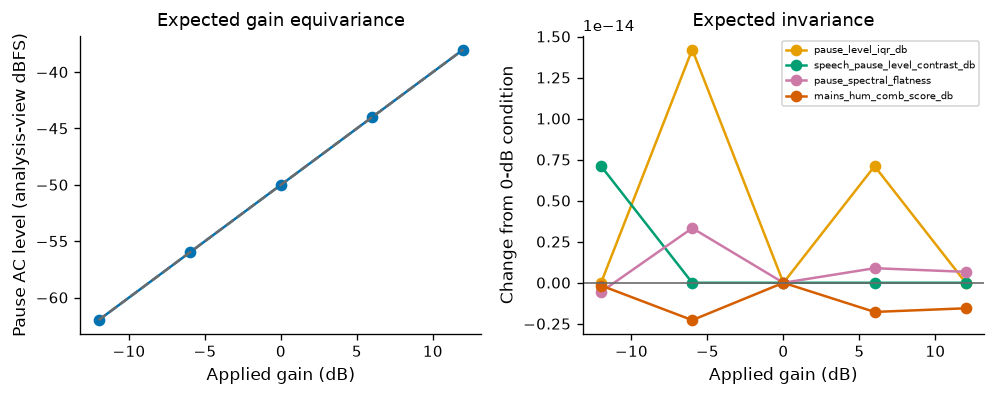

,layer,check,passed,observed,required,action_if_failed,blocking
0,formula,sine AC-RMS amplitude,True,0.0707106781187,0.0707106781187,repair RMS implementation,True
1,formula,sine AC-RMS dBFS,True,-23.0102999566,-23.0102999566,repair dB transform,True
2,transform,absolute level gain equivariance,True,24.000000000 dB,24 dB,repair level scale,True
3,transform,relative/shape gain invariance,True,"{""qadd_pause_level_iqr_db"": 1.4210854715202004...",<=1e-8,repair feature transform,True
4,reconstruction,all raw estimands reconstructed,True,11/11,11/11,repair ledger or aggregation,True
5,range,flatness bounded,True,0.5630–0.5630,"[0,1]",repair flatness,True


In [4]:
FS = PARAMETERS.analysis_sample_rate_hz


def synthetic_recording(
    noise_dbfs: float = -50.0,
    *,
    noise_kind: str = "white",
    amplitude_modulated: bool = False,
    hum_hz: float | None = None,
    hum_dbfs: float = -35.0,
    gain: float = 1.0,
    seed: int = 1,
):
    duration = 16.0
    time = np.arange(int(duration * FS)) / FS
    local_rng = np.random.default_rng(seed)
    speech = [
        TimeInterval(0.0, 2.0), TimeInterval(3.0, 5.0), TimeInterval(6.0, 8.0),
        TimeInterval(9.0, 11.0), TimeInterval(12.0, 16.0),
    ]
    pauses = [
        TimeInterval(2.0, 3.0), TimeInterval(5.0, 6.0),
        TimeInterval(8.0, 9.0), TimeInterval(11.0, 12.0),
    ]
    white = local_rng.normal(size=time.size)
    if noise_kind == "white":
        noise = white
    elif noise_kind == "pink":
        noise = signal.lfilter([1.0], [1.0, -0.985], white)
    elif noise_kind == "tone":
        noise = np.sqrt(2.0) * np.sin(2 * np.pi * 437.0 * time)
    else:
        raise ValueError(noise_kind)
    noise = noise - np.mean(noise)
    noise = noise / np.sqrt(np.mean(noise * noise))
    if amplitude_modulated:
        envelope = 0.10 + 0.90 * (0.5 + 0.5 * np.sin(2 * np.pi * 0.55 * time)) ** 2
        noise = noise * envelope
        noise = noise / np.sqrt(np.mean(noise * noise))
    waveform = noise * 10 ** (noise_dbfs / 20.0)
    speech_mask = np.zeros(time.size, dtype=bool)
    for interval in speech:
        speech_mask[int(interval.start_sec * FS):int(interval.end_sec * FS)] = True
    waveform[speech_mask] += 0.05 * np.sin(2 * np.pi * 180.0 * time[speech_mask])
    if hum_hz is not None:
        hum = np.zeros_like(waveform)
        amplitude = np.sqrt(2.0) * 10 ** (hum_dbfs / 20.0)
        for harmonic, weight in [(1, 1.0), (2, 0.6), (3, 0.35), (4, 0.2)]:
            hum += amplitude * weight * np.sin(2 * np.pi * hum_hz * harmonic * time)
        waveform += hum
    return waveform * gain, speech, pauses


sine_time = np.arange(int(0.03 * FS)) / FS
sine = 0.1 * np.sin(2 * np.pi * 1000.0 * sine_time)
observed_sine_db, observed_sine_rms, _, _ = ac_rms_measurement(sine)
expected_sine_rms = 0.1 / np.sqrt(2.0)
expected_sine_db = 20 * np.log10(expected_sine_rms)

base_waveform, synthetic_speech, synthetic_pauses = synthetic_recording(seed=310)
gain_rows = []
extractions = {}
for gain_db in [-12, -6, 0, 6, 12]:
    extraction = extract_qadd(
        base_waveform * 10 ** (gain_db / 20.0),
        FS,
        primary_speech=synthetic_speech,
        strict_speech=synthetic_speech,
        strict_internal_nonspeech=synthetic_pauses,
        logical_recording_id=f"gain_{gain_db}",
    )
    extractions[gain_db] = extraction
    gain_rows.append({"gain_db": gain_db, **{feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES}})
gain_controls = pd.DataFrame(gain_rows)
reconstruction = compare_reconstruction(extractions[0])

shift = gain_controls.set_index("gain_db").loc[12, "qadd_pause_ac_level_dbfs_median"] - gain_controls.set_index("gain_db").loc[-12, "qadd_pause_ac_level_dbfs_median"]
invariant_features = [feature for feature in ANALYSIS_FEATURES if feature != "qadd_pause_ac_level_dbfs_median"]
invariant_spans = {
    feature: float(gain_controls[feature].max() - gain_controls[feature].min())
    for feature in invariant_features
}
formula_checks = validation_frame(
    [
        ValidationCheck("formula", "sine AC-RMS amplitude", np.isclose(observed_sine_rms, expected_sine_rms, atol=1e-12), f"{observed_sine_rms:.12g}", f"{expected_sine_rms:.12g}", "repair RMS implementation"),
        ValidationCheck("formula", "sine AC-RMS dBFS", np.isclose(observed_sine_db, expected_sine_db, atol=1e-12), f"{observed_sine_db:.12g}", f"{expected_sine_db:.12g}", "repair dB transform"),
        ValidationCheck("transform", "absolute level gain equivariance", np.isclose(shift, 24.0, atol=1e-8), f"{shift:.9f} dB", "24 dB", "repair level scale"),
        ValidationCheck("transform", "relative/shape gain invariance", max(invariant_spans.values()) <= 1e-8, json.dumps(invariant_spans), "<=1e-8", "repair feature transform"),
        ValidationCheck("reconstruction", "all raw estimands reconstructed", reconstruction["pass"].all(), f"{int(reconstruction['pass'].sum())}/{len(reconstruction)}", f"{len(reconstruction)}/{len(reconstruction)}", "repair ledger or aggregation"),
        ValidationCheck("range", "flatness bounded", gain_controls["qadd_pause_spectral_flatness"].between(0, 1).all(), f"{gain_controls['qadd_pause_spectral_flatness'].min():.4f}–{gain_controls['qadd_pause_spectral_flatness'].max():.4f}", "[0,1]", "repair flatness"),
    ]
)
save_table_bundle(gain_controls, TABLES, "qadd_v4_1_deterministic_gain_controls")
save_table_bundle(reconstruction, TABLES, "qadd_v4_1_reconstruction_control")
save_table_bundle(formula_checks, TABLES, "qadd_v4_1_formula_checks")

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.4))
axes[0].plot(gain_controls["gain_db"], gain_controls["qadd_pause_ac_level_dbfs_median"], "o-", color=OKABE_ITO["blue"])
axes[0].plot(gain_controls["gain_db"], gain_controls.loc[gain_controls["gain_db"].eq(0), "qadd_pause_ac_level_dbfs_median"].iloc[0] + gain_controls["gain_db"], "--", color=OKABE_ITO["grey"])
axes[0].set(xlabel="Applied gain (dB)", ylabel="Pause AC level (analysis-view dBFS)", title="Expected gain equivariance")
for feature, color in zip(invariant_features, [OKABE_ITO["orange"], OKABE_ITO["green"], OKABE_ITO["purple"], OKABE_ITO["vermillion"]]):
    centered = gain_controls[feature] - gain_controls.loc[gain_controls["gain_db"].eq(0), feature].iloc[0]
    axes[1].plot(gain_controls["gain_db"], centered, "o-", label=feature.replace("qadd_", ""), color=color)
axes[1].axhline(0, color=OKABE_ITO["grey"], linewidth=1)
axes[1].set(xlabel="Applied gain (dB)", ylabel="Change from 0-dB condition", title="Expected invariance")
axes[1].legend(fontsize=6)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qadd_formula_transform_validation",
    caption="Deterministic transform validation. Absolute pause AC level follows applied gain; relative and shape descriptors remain invariant.",
    alt_text="Two panels show a unit-slope pause-level response to applied gain and near-zero changes for gain-invariant descriptors.",
)
plt.show()
display(formula_checks)


## 4. QADD-specific mechanism and discriminant controls

Positive controls test response to additive-noise dose, nonstationarity, broadband
versus tonal structure, and 50/60-Hz harmonic interference. Negative/discriminant
controls test global-gain invariance where expected and off-grid tonal specificity.
Diagnostic or human-QC labels are not used.


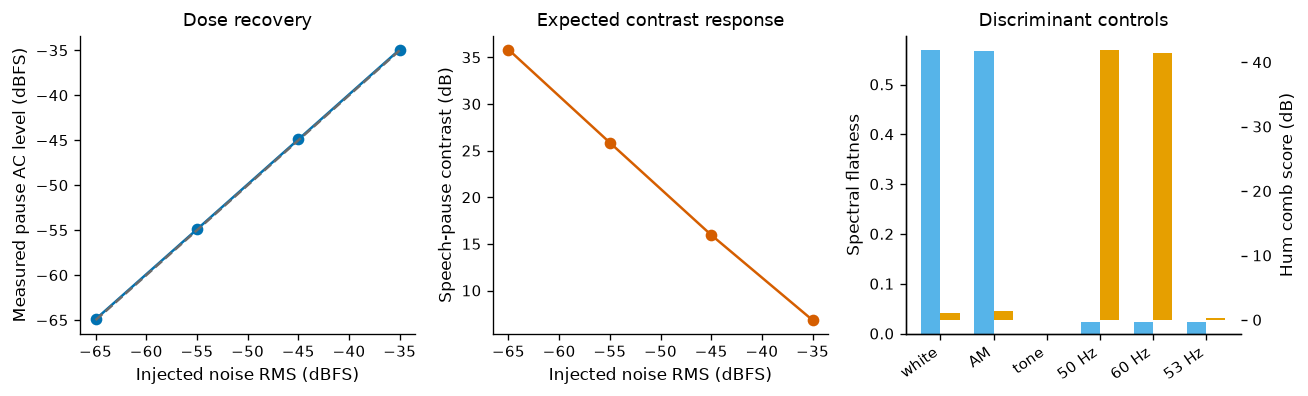

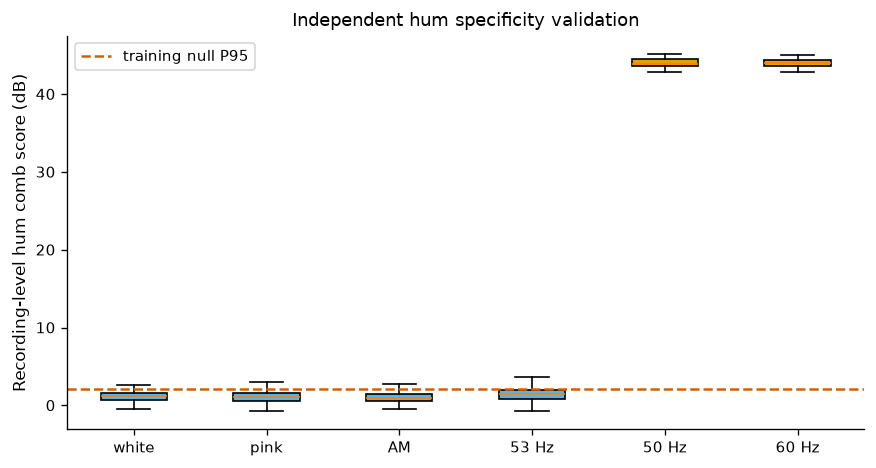

,layer,check,passed,observed,required,action_if_failed,blocking
0,mechanism,pause level monotonic with noise dose,True,rho=1.000,rho>=0.99,repair or redefine level estimator,True
1,mechanism,pause level recovers synthetic RMS dose,True,max error=0.095 dB,<=1 dB,repair scale/region definition,True
2,mechanism,contrast decreases with noise dose,True,rho=-1.000,rho<=-0.99,repair contrast or region definition,True
3,discriminant,amplitude modulation raises level IQR,True,14.55 vs 0.36,>3 dB separation,reassess IQR construct,True
4,discriminant,broadband flatness exceeds tonal flatness,True,0.569 vs 0.000,>0.25 separation,repair flatness or band definition,True
5,specificity,50-Hz hum exceeds off-grid comb,True,41.97 vs 0.37,>10 dB separation,redesign hum comb,True
6,specificity,60-Hz hum exceeds off-grid comb,True,41.50 vs 0.37,>10 dB separation,redesign hum comb,True
7,specificity,independent colored-noise false-positive control,True,rate=0.000; Wilson upper=0.013,Wilson 95% upper<=0.08,redesign hum comb or restrict claim,True
8,specificity,independent 53-Hz off-grid false-positive control,True,rate=0.000,<=0.05,redesign hum comb,True
9,mechanism,50/60-Hz injection sensitivity,True,sensitivity=1.000,>=0.95 at -32 dBFS,redesign hum comb or qualify sensitivity,True


In [5]:
mechanism_rows = []
for noise_dbfs in [-65, -55, -45, -35]:
    waveform, speech_intervals, pause_intervals = synthetic_recording(noise_dbfs=noise_dbfs, seed=410)
    result = extract_qadd(
        waveform, FS, primary_speech=speech_intervals, strict_speech=speech_intervals,
        strict_internal_nonspeech=pause_intervals, logical_recording_id=f"dose_{noise_dbfs}"
    ).recording
    mechanism_rows.append({"control": "white_noise_dose", "input_dbfs": noise_dbfs, **{feature: result[feature] for feature in ANALYSIS_FEATURES}})

descriptor_conditions = [
    ("white_stationary", dict(noise_kind="white", amplitude_modulated=False)),
    ("white_amplitude_modulated", dict(noise_kind="white", amplitude_modulated=True)),
    ("pink_stationary", dict(noise_kind="pink", amplitude_modulated=False)),
    ("offgrid_tonal_437hz", dict(noise_kind="tone", amplitude_modulated=False)),
    ("mains_hum_50hz", dict(noise_kind="white", hum_hz=50.0, hum_dbfs=-32.0)),
    ("mains_hum_60hz", dict(noise_kind="white", hum_hz=60.0, hum_dbfs=-32.0)),
    ("offgrid_comb_53hz", dict(noise_kind="white", hum_hz=53.0, hum_dbfs=-32.0)),
]
descriptor_rows = []
for name, kwargs in descriptor_conditions:
    waveform, speech_intervals, pause_intervals = synthetic_recording(noise_dbfs=-48, seed=411, **kwargs)
    result = extract_qadd(
        waveform, FS, primary_speech=speech_intervals, strict_speech=speech_intervals,
        strict_internal_nonspeech=pause_intervals, logical_recording_id=name
    ).recording
    descriptor_rows.append({"control": name, **{feature: result[feature] for feature in ANALYSIS_FEATURES}, "hum_winner_hz": result["qadd_mains_hum_winner_hz"]})

mechanism_controls = pd.DataFrame(mechanism_rows)
descriptor_controls = pd.DataFrame(descriptor_rows)
dose_rho_level = stats.spearmanr(mechanism_controls["input_dbfs"], mechanism_controls["qadd_pause_ac_level_dbfs_median"]).statistic
dose_rho_contrast = stats.spearmanr(mechanism_controls["input_dbfs"], mechanism_controls["qadd_speech_pause_level_contrast_db"]).statistic
level_error = np.abs(mechanism_controls["qadd_pause_ac_level_dbfs_median"] - mechanism_controls["input_dbfs"])
descriptors = descriptor_controls.set_index("control")

def simulated_hum_recording_score(
    condition: str,
    seed: int,
    *,
    injected_hum_hz: float | None = None,
    injected_hum_dbfs: float = -32.0,
    window_count: int = 8,
    return_details: bool = False,
):
    # Apply the authoritative comb to independent 500-ms synthetic windows.

    local_rng = np.random.default_rng(seed)
    window_n = int(round(PARAMETERS.hum_window_ms * FS / 1000.0))
    score_50, score_60 = [], []
    support_50, support_60 = [], []
    for window_index in range(window_count):
        samples = local_rng.normal(size=window_n)
        if condition == "pink":
            samples = signal.lfilter([1.0], [1.0, -0.985], samples)
        elif condition == "amplitude_modulated":
            local_time = np.arange(window_n) / FS
            envelope = 0.10 + 0.90 * (
                0.5
                + 0.5
                * np.sin(2 * np.pi * 0.55 * local_time + 0.3 * window_index)
            ) ** 2
            samples = samples * envelope
        elif condition != "white":
            raise ValueError(condition)
        samples = samples - np.mean(samples)
        samples = samples / np.sqrt(np.mean(samples * samples))
        samples = samples * 10 ** (-50.0 / 20.0)
        if injected_hum_hz is not None:
            local_time = np.arange(window_n) / FS
            amplitude = np.sqrt(2.0) * 10 ** (injected_hum_dbfs / 20.0)
            for harmonic, weight in [(1, 1.0), (2, 0.6), (3, 0.35), (4, 0.2)]:
                samples += (
                    amplitude
                    * weight
                    * np.sin(
                        2
                        * np.pi
                        * injected_hum_hz
                        * harmonic
                        * local_time
                    )
                )
        frequencies, psd = power_spectrum(samples, FS)
        result_50 = hum_comb_score_from_psd(
            frequencies, psd, 50.0, parameters=PARAMETERS
        )
        result_60 = hum_comb_score_from_psd(
            frequencies, psd, 60.0, parameters=PARAMETERS
        )
        score_50.append(result_50[0])
        score_60.append(result_60[0])
        support_50.append(result_50[1])
        support_60.append(result_60[1])
    recording_50 = float(np.median(score_50))
    recording_60 = float(np.median(score_60))
    if recording_50 >= recording_60:
        score = recording_50
        supported = float(np.median(support_50))
        winner_hz = 50.0
    else:
        score = recording_60
        supported = float(np.median(support_60))
        winner_hz = 60.0
    details = {
        "hum_comb_score_db": score,
        "supported_harmonic_count_median": supported,
        "winner_hz": winner_hz,
        "window_count": int(window_count),
    }
    return details if return_details else score


hum_null_training_rows = []
HUM_NULL_SUPPORT_GRID = [2, 4, 8, 12, 24]
for support_index, window_count in enumerate(HUM_NULL_SUPPORT_GRID):
    for condition_index, condition in enumerate(
        ["white", "pink", "amplitude_modulated"]
    ):
        for repeat_index in range(60):
            hum_null_training_rows.append(
                {
                    "set": "training",
                    "condition": condition,
                    "repeat": repeat_index,
                    "window_count": window_count,
                    "hum_comb_score_db": simulated_hum_recording_score(
                        condition,
                        7000
                        + 100000 * support_index
                        + 1000 * condition_index
                        + repeat_index,
                        window_count=window_count,
                    ),
                }
            )
hum_null_training = pd.DataFrame(hum_null_training_rows)
hum_null_thresholds = (
    hum_null_training.groupby("window_count", as_index=False)["hum_comb_score_db"]
    .quantile(0.95)
    .rename(columns={"hum_comb_score_db": "null_p95_db"})
)
hum_null_threshold_db = float(
    hum_null_thresholds.set_index("window_count").loc[8, "null_p95_db"]
)

hum_null_evaluation_rows = []
for condition_index, condition in enumerate(
    ["white", "pink", "amplitude_modulated"]
):
    for repeat_index in range(100):
        simulated = simulated_hum_recording_score(
            condition,
            12000 + 1000 * condition_index + repeat_index,
            return_details=True,
        )
        hum_null_evaluation_rows.append(
            {
                "set": "independent_evaluation",
                "condition": condition,
                "expected_positive": False,
                "repeat": repeat_index,
                **simulated,
            }
        )
for repeat_index in range(100):
    simulated = simulated_hum_recording_score(
        "white",
        16000 + repeat_index,
        injected_hum_hz=53.0,
        return_details=True,
    )
    hum_null_evaluation_rows.append(
        {
            "set": "independent_evaluation",
            "condition": "offgrid_comb_53hz",
            "expected_positive": False,
            "repeat": repeat_index,
            **simulated,
        }
    )
for fundamental_index, fundamental_hz in enumerate([50.0, 60.0]):
    for repeat_index in range(50):
        simulated = simulated_hum_recording_score(
            "white",
            17000 + 1000 * fundamental_index + repeat_index,
            injected_hum_hz=fundamental_hz,
            return_details=True,
        )
        hum_null_evaluation_rows.append(
            {
                "set": "independent_evaluation",
                "condition": f"mains_comb_{int(fundamental_hz)}hz",
                "expected_positive": True,
                "repeat": repeat_index,
                **simulated,
            }
        )
hum_null_evaluation = pd.DataFrame(hum_null_evaluation_rows)
hum_null_evaluation["above_training_p95"] = hum_null_evaluation[
    "hum_comb_score_db"
].gt(hum_null_threshold_db)
hum_null_evaluation["joint_hum_evidence"] = (
    hum_null_evaluation["above_training_p95"]
    & hum_null_evaluation["supported_harmonic_count_median"].ge(
        PARAMETERS.hum_min_supported_harmonics
    )
)
colored_null = hum_null_evaluation.loc[
    hum_null_evaluation["condition"].isin(
        ["white", "pink", "amplitude_modulated"]
    )
]
offgrid_null = hum_null_evaluation.loc[
    hum_null_evaluation["condition"].eq("offgrid_comb_53hz")
]
mains_positive = hum_null_evaluation.loc[
    hum_null_evaluation["expected_positive"].astype(bool)
]

def wilson_upper(successes: int, trials: int, z: float = 1.96) -> float:
    proportion = successes / trials
    denominator = 1.0 + z * z / trials
    center = (proportion + z * z / (2.0 * trials)) / denominator
    radius = (
        z
        * np.sqrt(
            proportion * (1.0 - proportion) / trials
            + z * z / (4.0 * trials * trials)
        )
        / denominator
    )
    return float(center + radius)


colored_false_positive_rate = float(colored_null["joint_hum_evidence"].mean())
colored_false_positive_upper = wilson_upper(
    int(colored_null["joint_hum_evidence"].sum()), len(colored_null)
)
offgrid_false_positive_rate = float(offgrid_null["joint_hum_evidence"].mean())
mains_sensitivity = float(mains_positive["joint_hum_evidence"].mean())
hum_null_summary = pd.DataFrame(
    [
        {
            "training_p95_db": hum_null_threshold_db,
            "colored_noise_false_positive_rate": colored_false_positive_rate,
            "colored_noise_false_positive_wilson95_upper": colored_false_positive_upper,
            "offgrid_53hz_false_positive_rate": offgrid_false_positive_rate,
            "mains_50_60hz_sensitivity_at_minus32dbfs": mains_sensitivity,
            "training_n": len(hum_null_training),
            "evaluation_n": len(hum_null_evaluation),
        }
    ]
)

mechanism_checks = validation_frame(
    [
        ValidationCheck("mechanism", "pause level monotonic with noise dose", dose_rho_level >= 0.99, f"rho={dose_rho_level:.3f}", "rho>=0.99", "repair or redefine level estimator"),
        ValidationCheck("mechanism", "pause level recovers synthetic RMS dose", level_error.max() <= 1.0, f"max error={level_error.max():.3f} dB", "<=1 dB", "repair scale/region definition"),
        ValidationCheck("mechanism", "contrast decreases with noise dose", dose_rho_contrast <= -0.99, f"rho={dose_rho_contrast:.3f}", "rho<=-0.99", "repair contrast or region definition"),
        ValidationCheck("discriminant", "amplitude modulation raises level IQR", descriptors.loc["white_amplitude_modulated", "qadd_pause_level_iqr_db"] > descriptors.loc["white_stationary", "qadd_pause_level_iqr_db"] + 3.0, f"{descriptors.loc['white_amplitude_modulated', 'qadd_pause_level_iqr_db']:.2f} vs {descriptors.loc['white_stationary', 'qadd_pause_level_iqr_db']:.2f}", ">3 dB separation", "reassess IQR construct"),
        ValidationCheck("discriminant", "broadband flatness exceeds tonal flatness", descriptors.loc["white_stationary", "qadd_pause_spectral_flatness"] > descriptors.loc["offgrid_tonal_437hz", "qadd_pause_spectral_flatness"] + 0.25, f"{descriptors.loc['white_stationary', 'qadd_pause_spectral_flatness']:.3f} vs {descriptors.loc['offgrid_tonal_437hz', 'qadd_pause_spectral_flatness']:.3f}", ">0.25 separation", "repair flatness or band definition"),
        ValidationCheck("specificity", "50-Hz hum exceeds off-grid comb", descriptors.loc["mains_hum_50hz", "qadd_mains_hum_comb_score_db"] > descriptors.loc["offgrid_comb_53hz", "qadd_mains_hum_comb_score_db"] + 10.0, f"{descriptors.loc['mains_hum_50hz', 'qadd_mains_hum_comb_score_db']:.2f} vs {descriptors.loc['offgrid_comb_53hz', 'qadd_mains_hum_comb_score_db']:.2f}", ">10 dB separation", "redesign hum comb"),
        ValidationCheck("specificity", "60-Hz hum exceeds off-grid comb", descriptors.loc["mains_hum_60hz", "qadd_mains_hum_comb_score_db"] > descriptors.loc["offgrid_comb_53hz", "qadd_mains_hum_comb_score_db"] + 10.0, f"{descriptors.loc['mains_hum_60hz', 'qadd_mains_hum_comb_score_db']:.2f} vs {descriptors.loc['offgrid_comb_53hz', 'qadd_mains_hum_comb_score_db']:.2f}", ">10 dB separation", "redesign hum comb"),
        ValidationCheck("specificity", "independent colored-noise false-positive control", colored_false_positive_upper <= 0.08, f"rate={colored_false_positive_rate:.3f}; Wilson upper={colored_false_positive_upper:.3f}", "Wilson 95% upper<=0.08", "redesign hum comb or restrict claim"),
        ValidationCheck("specificity", "independent 53-Hz off-grid false-positive control", offgrid_false_positive_rate <= 0.05, f"rate={offgrid_false_positive_rate:.3f}", "<=0.05", "redesign hum comb"),
        ValidationCheck("mechanism", "50/60-Hz injection sensitivity", mains_sensitivity >= 0.95, f"sensitivity={mains_sensitivity:.3f}", ">=0.95 at -32 dBFS", "redesign hum comb or qualify sensitivity"),
    ]
)
save_table_bundle(mechanism_controls, TABLES, "qadd_v4_1_mechanism_noise_dose")
save_table_bundle(descriptor_controls, TABLES, "qadd_v4_1_mechanism_descriptors")
save_table_bundle(hum_null_training, TABLES, "qadd_v4_1_hum_null_training")
save_table_bundle(hum_null_thresholds, TABLES, "qadd_v4_1_hum_null_thresholds_by_support")
save_table_bundle(hum_null_evaluation, TABLES, "qadd_v4_1_hum_null_independent_evaluation")
save_table_bundle(hum_null_summary, TABLES, "qadd_v4_1_hum_null_summary")
save_table_bundle(mechanism_checks, TABLES, "qadd_v4_1_mechanism_checks")

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.4))
axes[0].plot(mechanism_controls["input_dbfs"], mechanism_controls["qadd_pause_ac_level_dbfs_median"], "o-", color=OKABE_ITO["blue"])
axes[0].plot(mechanism_controls["input_dbfs"], mechanism_controls["input_dbfs"], "--", color=OKABE_ITO["grey"])
axes[0].set(xlabel="Injected noise RMS (dBFS)", ylabel="Measured pause AC level (dBFS)", title="Dose recovery")
axes[1].plot(mechanism_controls["input_dbfs"], mechanism_controls["qadd_speech_pause_level_contrast_db"], "o-", color=OKABE_ITO["vermillion"])
axes[1].set(xlabel="Injected noise RMS (dBFS)", ylabel="Speech-pause contrast (dB)", title="Expected contrast response")
selected = descriptor_controls.set_index("control").loc[["white_stationary", "white_amplitude_modulated", "offgrid_tonal_437hz", "mains_hum_50hz", "mains_hum_60hz", "offgrid_comb_53hz"]]
x = np.arange(len(selected))
axes[2].bar(x - 0.18, selected["qadd_pause_spectral_flatness"], width=0.36, color=OKABE_ITO["sky"], label="flatness")
ax2 = axes[2].twinx()
ax2.bar(x + 0.18, selected["qadd_mains_hum_comb_score_db"], width=0.36, color=OKABE_ITO["orange"], label="hum comb")
axes[2].set_xticks(x, ["white", "AM", "tone", "50 Hz", "60 Hz", "53 Hz"], rotation=35, ha="right")
axes[2].set_ylabel("Spectral flatness")
ax2.set_ylabel("Hum comb score (dB)")
axes[2].set_title("Discriminant controls")
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qadd_synthetic_construct_validity",
    caption="Synthetic construct validation for QADD v4.1: additive-noise dose recovery, expected speech-pause contrast response, and discriminant spectral controls.",
    alt_text="Three panels show measured noise level tracking injected dose, contrast decreasing with dose, and distinct responses to broadband, modulated, tonal, mains-hum, and off-grid controls.",
)
plt.show()

fig, ax = plt.subplots(figsize=(7.4, 4.0))
hum_order = [
    "white",
    "pink",
    "amplitude_modulated",
    "offgrid_comb_53hz",
    "mains_comb_50hz",
    "mains_comb_60hz",
]
hum_groups = [
    hum_null_evaluation.loc[
        hum_null_evaluation["condition"].eq(condition),
        "hum_comb_score_db",
    ].to_numpy()
    for condition in hum_order
]
try:
    boxes = ax.boxplot(
        hum_groups,
        tick_labels=["white", "pink", "AM", "53 Hz", "50 Hz", "60 Hz"],
        patch_artist=True,
        showfliers=False,
    )
except TypeError:
    boxes = ax.boxplot(
        hum_groups,
        labels=["white", "pink", "AM", "53 Hz", "50 Hz", "60 Hz"],
        patch_artist=True,
        showfliers=False,
    )
for index, box in enumerate(boxes["boxes"]):
    box.set_facecolor(
        OKABE_ITO["sky"] if index < 4 else OKABE_ITO["orange"]
    )
ax.axhline(
    hum_null_threshold_db,
    color=OKABE_ITO["vermillion"],
    linestyle="--",
    label="training null P95",
)
ax.set(
    ylabel="Recording-level hum comb score (dB)",
    title="Independent hum specificity validation",
)
ax.legend()
fig.tight_layout()
save_publication_figure(
    fig,
    FIGURES,
    "figure_qadd_hum_specificity_validation",
    caption="Independent specificity validation of the QADD mains-hum comb. The horizontal line is the eight-window P95 from a separate colored-noise training set; positive hum evidence additionally requires at least three supported low-order harmonics.",
    alt_text="Boxplots compare hum-comb scores for white, pink, amplitude-modulated, off-grid 53-Hz, and positive 50/60-Hz harmonic controls against a separately calibrated score threshold, with harmonic-consistency required for classification.",
)
plt.show()
display(mechanism_checks)


## 5. Digital-floor censoring calibration

The estimator is calibrated under **level-dependent** censoring: the lowest-level
pause frames are removed first. This is more conservative than random missingness.
The configured censoring ceiling may be retained only if the 90th-percentile absolute
bias remains within 1 dB for median level/contrast and 1.5 dB for IQR across stationary
white, colored, and amplitude-modulated controls.


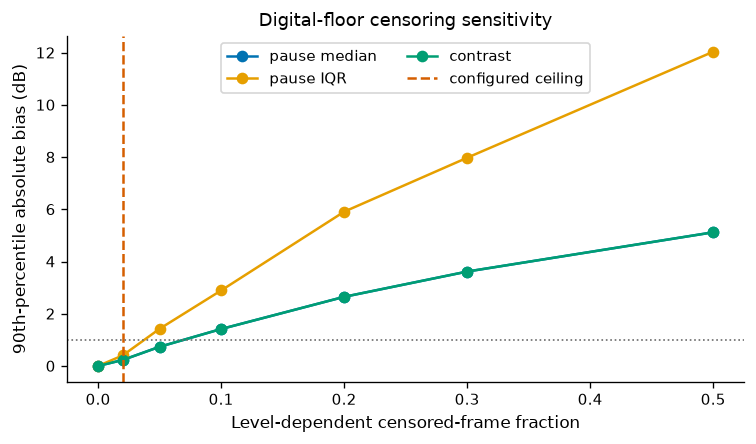

,censored_fraction,level_abs_bias_p90_db,iqr_abs_bias_p90_db,contrast_abs_bias_p90_db,within_bias_contract
0,0.00,0.000000,0.000000,0.000000,True
1,0.02,0.227866,0.402622,0.227866,True
2,0.05,0.734161,1.423273,0.734161,True
3,0.10,1.414239,2.890950,1.414239,False
4,0.20,2.647239,5.907915,2.647239,False
5,0.30,3.615371,7.975113,3.615371,False
6,0.50,5.119500,12.036108,5.119500,False


,layer,check,passed,observed,required,action_if_failed,blocking
0,censoring,configured floor ceiling no larger than calibr...,True,configured=0.02; calibrated=0.05,configured<=calibrated,lower configured ceiling or revise estimator,True
1,censoring,calibration includes nonstationary control,True,included,included,add nonstationary simulation,True
2,censoring,censored raw estimates never silently published,True,status=floor_censored; published=nan; raw=-49.986,"floor_censored status, NaN analysis value, fin...",repair status contract,True


In [6]:
censoring_rows = []
fractions = [0.00, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
conditions = [
    ("white", dict(noise_kind="white", amplitude_modulated=False)),
    ("pink", dict(noise_kind="pink", amplitude_modulated=False)),
    ("amplitude_modulated", dict(noise_kind="white", amplitude_modulated=True)),
]
frame_n = round(PARAMETERS.frame_ms * FS / 1000.0)
hop_n = round(PARAMETERS.hop_ms * FS / 1000.0)
calibration_support_sec = [0.5, 1.5, 3.0, 6.0]
for condition_index, (condition, kwargs) in enumerate(conditions):
    for support_index, support_sec in enumerate(calibration_support_sec):
        for repeat_index in range(30):
            local_rng = np.random.default_rng(
                5000
                + 10000 * condition_index
                + 1000 * support_index
                + repeat_index
            )
            sample_count = round(support_sec * FS)
            pause_waveform = local_rng.normal(size=sample_count)
            if kwargs["noise_kind"] == "pink":
                pause_waveform = signal.lfilter(
                    [1.0], [1.0, -0.985], pause_waveform
                )
            if kwargs["amplitude_modulated"]:
                local_time = np.arange(sample_count) / FS
                envelope = 0.10 + 0.90 * (
                    0.5 + 0.5 * np.sin(2 * np.pi * 0.55 * local_time)
                ) ** 2
                pause_waveform = pause_waveform * envelope
            pause_waveform = pause_waveform - np.mean(pause_waveform)
            pause_waveform = (
                pause_waveform
                / np.sqrt(np.mean(pause_waveform * pause_waveform))
                * 10 ** (-50.0 / 20.0)
            )
            pause_levels = np.asarray(
                [
                    ac_rms_measurement(
                        pause_waveform[start : start + frame_n],
                        floor_db=PARAMETERS.dbfs_floor_db,
                    )[0]
                    for start in range(
                        0, sample_count - frame_n + 1, hop_n
                    )
                ]
            )
            speech_median_dbfs = -25.0
            baseline_level = np.median(pause_levels)
            baseline_iqr = np.quantile(
                pause_levels, 0.75
            ) - np.quantile(pause_levels, 0.25)
            baseline_contrast = speech_median_dbfs - baseline_level
            ordered = np.sort(pause_levels)
            for fraction in fractions:
                remove_n = int(np.floor(fraction * len(ordered)))
                retained = ordered[remove_n:]
                level = np.median(retained)
                iqr = np.quantile(retained, 0.75) - np.quantile(
                    retained, 0.25
                )
                contrast = speech_median_dbfs - level
                censoring_rows.append(
                    {
                        "condition": condition,
                        "support_sec": support_sec,
                        "repeat": repeat_index,
                        "censored_fraction": fraction,
                        "pause_level_bias_db": level - baseline_level,
                        "pause_iqr_bias_db": iqr - baseline_iqr,
                        "contrast_bias_db": contrast - baseline_contrast,
                    }
                )
censoring_bias = pd.DataFrame(censoring_rows)
censoring_summary = (
    censoring_bias.assign(
        abs_level=lambda x: x["pause_level_bias_db"].abs(),
        abs_iqr=lambda x: x["pause_iqr_bias_db"].abs(),
        abs_contrast=lambda x: x["contrast_bias_db"].abs(),
    )
    .groupby("censored_fraction", as_index=False)
    .agg(
        level_abs_bias_p90_db=("abs_level", lambda values: np.quantile(values, 0.90)),
        iqr_abs_bias_p90_db=("abs_iqr", lambda values: np.quantile(values, 0.90)),
        contrast_abs_bias_p90_db=("abs_contrast", lambda values: np.quantile(values, 0.90)),
    )
)
censoring_summary["within_bias_contract"] = (
    censoring_summary["level_abs_bias_p90_db"].le(1.0)
    & censoring_summary["iqr_abs_bias_p90_db"].le(1.5)
    & censoring_summary["contrast_abs_bias_p90_db"].le(1.0)
)
calibrated_limit = float(censoring_summary.loc[censoring_summary["within_bias_contract"], "censored_fraction"].max())
floor_waveform, floor_speech, floor_pauses = synthetic_recording(noise_dbfs=-50, seed=5900)
floor_waveform[
    int(floor_pauses[0].start_sec * FS):int(floor_pauses[0].end_sec * FS)
] = 0.0
floor_example = extract_qadd(
    floor_waveform, FS, primary_speech=floor_speech, strict_speech=floor_speech,
    strict_internal_nonspeech=floor_pauses, logical_recording_id="floor_censoring_control"
).recording
floor_checks = validation_frame(
    [
        ValidationCheck("censoring", "configured floor ceiling no larger than calibration", PARAMETERS.maximum_floor_censored_fraction <= calibrated_limit, f"configured={PARAMETERS.maximum_floor_censored_fraction:.2f}; calibrated={calibrated_limit:.2f}", "configured<=calibrated", "lower configured ceiling or revise estimator"),
        ValidationCheck("censoring", "calibration includes nonstationary control", "amplitude_modulated" in set(censoring_bias["condition"]), "included", "included", "add nonstationary simulation"),
        ValidationCheck(
            "censoring",
            "censored raw estimates never silently published",
            floor_example["qadd_pause_ac_level_dbfs_median_status"] == "floor_censored"
            and np.isnan(floor_example["qadd_pause_ac_level_dbfs_median"])
            and np.isfinite(floor_example["qadd_pause_ac_level_dbfs_median_raw_estimate"]),
            f"status={floor_example['qadd_pause_ac_level_dbfs_median_status']}; published={floor_example['qadd_pause_ac_level_dbfs_median']}; raw={floor_example['qadd_pause_ac_level_dbfs_median_raw_estimate']:.3f}",
            "floor_censored status, NaN analysis value, finite raw audit estimate",
            "repair status contract",
        ),
    ]
)
save_table_bundle(censoring_bias, TABLES, "qadd_v4_1_floor_censoring_bias_long")
save_table_bundle(censoring_summary, TABLES, "qadd_v4_1_floor_censoring_bias_summary")
save_table_bundle(floor_checks, TABLES, "qadd_v4_1_floor_censoring_checks")

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(censoring_summary["censored_fraction"], censoring_summary["level_abs_bias_p90_db"], "o-", label="pause median", color=OKABE_ITO["blue"])
ax.plot(censoring_summary["censored_fraction"], censoring_summary["iqr_abs_bias_p90_db"], "o-", label="pause IQR", color=OKABE_ITO["orange"])
ax.plot(censoring_summary["censored_fraction"], censoring_summary["contrast_abs_bias_p90_db"], "o-", label="contrast", color=OKABE_ITO["green"])
ax.axvline(PARAMETERS.maximum_floor_censored_fraction, color=OKABE_ITO["vermillion"], linestyle="--", label="configured ceiling")
ax.axhline(1.0, color=OKABE_ITO["grey"], linestyle=":", linewidth=1)
ax.set(xlabel="Level-dependent censored-frame fraction", ylabel="90th-percentile absolute bias (dB)", title="Digital-floor censoring sensitivity")
ax.legend(ncol=2)
fig.tight_layout()
save_publication_figure(
    fig, FIGURES, "figure_qadd_floor_censoring_calibration",
    caption="Level-dependent digital-floor censoring calibration across white, colored, and amplitude-modulated pause controls with 0.5–6.0 s support.",
    alt_text="Line plot of 90th-percentile absolute bias in pause median, IQR, and speech-pause contrast across 0.5–6.0 seconds of support as the lowest-level frame fraction is censored.",
)
plt.show()
display(censoring_summary)
display(floor_checks)


## 6. Codec and signal-chain robustness

Lossy coding can add or reshape low-level pause energy. The synthetic round-trip is
therefore a required engineering check, not proof that all real recordings are codec
invariant. Real-cohort results later report codec-stratified distributions and
analysis-view availability.


In [7]:
codec_rows = []
codec_checks_list = []
if RUN_CODEC_ROUNDTRIP:
    waveform, speech_intervals, pause_intervals = synthetic_recording(noise_dbfs=-40, seed=610)
    reference = extract_qadd(
        waveform, FS, primary_speech=speech_intervals, strict_speech=speech_intervals,
        strict_internal_nonspeech=pause_intervals, logical_recording_id="pcm_reference"
    ).recording
    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg and ffprobe:
        with TemporaryDirectory(prefix="qadd_codec_") as temp:
            temp = Path(temp)
            wav = temp / "reference.wav"
            sf.write(wav, waveform, FS, subtype="PCM_24")
            variants = {"pcm24_wav": wav}
            commands = {
                "mp3_128k": [ffmpeg, "-nostdin", "-y", "-v", "error", "-i", str(wav), "-b:a", "128k", str(temp / "roundtrip.mp3")],
                "opus_48k": [ffmpeg, "-nostdin", "-y", "-v", "error", "-i", str(wav), "-c:a", "libopus", "-b:a", "48k", str(temp / "roundtrip.ogg")],
            }
            for name, command in commands.items():
                completed = subprocess.run(command, capture_output=True, text=True)
                if completed.returncode == 0:
                    variants[name] = Path(command[-1])
                else:
                    codec_rows.append({"codec": name, "decode_status": "encode_failed", "message": completed.stderr})
            for name, path in variants.items():
                views = decode_audio_views(path, ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS)
                local = extract_qadd(
                    views.analysis_16k, FS, primary_speech=speech_intervals, strict_speech=speech_intervals,
                    strict_internal_nonspeech=pause_intervals, logical_recording_id=name
                ).recording
                row = {"codec": name, "decode_status": "ok"}
                for feature in ANALYSIS_FEATURES:
                    row[feature] = local[feature]
                    row[f"{feature}_difference"] = local[feature] - reference[feature]
                codec_rows.append(row)
    else:
        codec_rows.append({"codec": "all", "decode_status": "not_run", "message": "ffmpeg/ffprobe missing"})
else:
    codec_rows.append({"codec": "all", "decode_status": "not_run", "message": "disabled"})

codec_robustness = pd.DataFrame(codec_rows)
successful_codecs = codec_robustness.loc[codec_robustness["decode_status"].eq("ok")].copy()
lossy = successful_codecs.loc[~successful_codecs["codec"].eq("pcm24_wav")]
codec_checks = validation_frame(
    [
        ValidationCheck("codec", "PCM and two lossy round-trips completed", len(successful_codecs) >= 3, str(list(successful_codecs.get("codec", []))), "PCM, MP3, Opus", "install codecs or document unsupported format"),
        ValidationCheck("codec", "pause level stable at representative dose", len(lossy) >= 2 and lossy["qadd_pause_ac_level_dbfs_median_difference"].abs().max() <= 1.5, f"max={lossy['qadd_pause_ac_level_dbfs_median_difference'].abs().max() if len(lossy) else np.nan:.3f} dB", "<=1.5 dB", "quantify codec dependence and stratify analysis"),
        ValidationCheck("codec", "contrast stable at representative dose", len(lossy) >= 2 and lossy["qadd_speech_pause_level_contrast_db_difference"].abs().max() <= 1.5, f"max={lossy['qadd_speech_pause_level_contrast_db_difference'].abs().max() if len(lossy) else np.nan:.3f} dB", "<=1.5 dB", "quantify codec dependence and stratify analysis"),
        ValidationCheck("codec", "flatness stable at representative dose", len(lossy) >= 2 and lossy["qadd_pause_spectral_flatness_difference"].abs().max() <= 0.10, f"max={lossy['qadd_pause_spectral_flatness_difference'].abs().max() if len(lossy) else np.nan:.3f}", "<=0.10", "quantify codec dependence and stratify analysis"),
    ]
)
save_table_bundle(codec_robustness, TABLES, "qadd_v4_1_codec_roundtrip")
save_table_bundle(codec_checks, TABLES, "qadd_v4_1_codec_checks")
display(codec_robustness)
display(codec_checks)


,codec,decode_status,qadd_pause_ac_level_dbfs_median,qadd_pause_ac_level_dbfs_median_difference,qadd_pause_level_iqr_db,qadd_pause_level_iqr_db_difference,qadd_speech_pause_level_contrast_db,qadd_speech_pause_level_contrast_db_difference,qadd_pause_spectral_flatness,qadd_pause_spectral_flatness_difference,qadd_mains_hum_comb_score_db,qadd_mains_hum_comb_score_db_difference
0,pcm24_wav,ok,-40.031241,-0.000001,0.361822,9.968467e-07,11.324501,0.000001,0.563938,5.081839e-08,1.204035,0.000017
1,mp3_128k,ok,-40.896137,-0.864897,0.387171,2.535038e-02,11.713575,0.389075,0.564365,4.268445e-04,1.148612,-0.055406
2,opus_48k,ok,-40.346980,-0.315741,0.873560,5.117398e-01,11.614735,0.290235,0.556229,-7.709218e-03,0.867143,-0.336875


,layer,check,passed,observed,required,action_if_failed,blocking
0,codec,PCM and two lossy round-trips completed,True,"['pcm24_wav', 'mp3_128k', 'opus_48k']","PCM, MP3, Opus",install codecs or document unsupported format,True
1,codec,pause level stable at representative dose,True,max=0.865 dB,<=1.5 dB,quantify codec dependence and stratify analysis,True
2,codec,contrast stable at representative dose,True,max=0.389 dB,<=1.5 dB,quantify codec dependence and stratify analysis,True
3,codec,flatness stable at representative dose,True,max=0.008,<=0.10,quantify codec dependence and stratify analysis,True


## 7. Full-cohort extraction from frozen segments

One row is produced for every eligible recording, including explicit error/status
rows. Frame, interval, and spectral-window ledgers make every raw estimate
reconstructable. No diagnostic or human-QC field enters extraction.


In [8]:
def intervals_for(recording_id: str, view: str) -> list[TimeInterval]:
    local = frozen["intervals"].loc[
        frozen["intervals"]["logical_recording_id"].eq(str(recording_id))
        & frozen["intervals"]["view"].astype(str).eq(str(view))
    ]
    return [TimeInterval(float(row.start_sec), float(row.end_sec)) for row in local.itertuples(index=False)]


def media_path_for(row) -> Path:
    path = Path(str(row.media_path))
    return path if path.is_absolute() else ROOT / path


recording_table = pd.DataFrame()
frame_ledger = pd.DataFrame()
interval_ledger = pd.DataFrame()
spectral_ledger = pd.DataFrame()
extraction_errors = pd.DataFrame(columns=["logical_recording_id", "error_type", "message"])

if RUN_COHORT_EXTRACTION:
    def hum_null_reference_for_count(valid_window_count: int) -> tuple[int, float]:
        # Use the largest calibrated count not exceeding observed
        # support. The null distribution narrows as a median is
        # estimated from more windows, so the next-lower calibrated
        # count is a conservative binned match. Counts above the grid
        # use the largest reference; counts below two are unavailable.

        count = int(valid_window_count)
        eligible = hum_null_thresholds.loc[
            hum_null_thresholds["window_count"].le(count)
        ]
        if eligible.empty:
            selected = hum_null_thresholds.sort_values("window_count").iloc[0]
        else:
            selected = eligible.sort_values("window_count").iloc[-1]
        return int(selected["window_count"]), float(selected["null_p95_db"])

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg and ffprobe are required for cohort extraction")
    recording_rows, frame_parts, interval_parts, spectral_parts, error_rows = [], [], [], [], []
    for row in frozen["recordings"].itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        try:
            views = decode_audio_views(media_path_for(row), ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS)
            primary = intervals_for(recording_id, frozen["primary_view"])
            strict_speech = intervals_for(recording_id, frozen["strict_speech_view"])
            strict_pause = intervals_for(recording_id, frozen["strict_pause_view"])
            extraction = extract_qadd(
                views.analysis_16k, FS,
                primary_speech=primary, strict_speech=strict_speech,
                strict_internal_nonspeech=strict_pause,
                logical_recording_id=recording_id,
            )
            calibrated_recording = extraction.recording
            if int(calibrated_recording["qadd_hum_valid_window_count"]) >= PARAMETERS.hum_min_windows:
                reference_count, null_p95 = hum_null_reference_for_count(
                    calibrated_recording["qadd_hum_valid_window_count"]
                )
                calibrated_recording = apply_hum_null_calibration(
                    calibrated_recording,
                    null_p95,
                    minimum_supported_harmonics=PARAMETERS.hum_min_supported_harmonics,
                )
                calibrated_recording["qadd_mains_hum_null_reference_window_count"] = reference_count
                calibrated_recording["qadd_mains_hum_null_calibration_status"] = (
                    "applied_exact_count"
                    if reference_count == int(calibrated_recording["qadd_hum_valid_window_count"])
                    else "applied_conservative_support_bin"
                )
            else:
                calibrated_recording["qadd_mains_hum_null_reference_window_count"] = pd.NA
            recording_rows.append(
                {
                    **calibrated_recording,
                    "file_name": getattr(row, "file_name", media_path_for(row).name),
                    "media_path": str(media_path_for(row)),
                    "native_sample_rate_hz": views.sample_rate_native,
                    "native_channels": views.native.shape[1],
                    "codec_name": views.probe.get("codec_name"),
                }
            )
            frame_parts.append(extraction.frame_ledger)
            interval_parts.append(extraction.interval_ledger)
            spectral_parts.append(extraction.spectral_ledger)
        except Exception as exc:
            error_rows.append({"logical_recording_id": recording_id, "error_type": type(exc).__name__, "message": str(exc)})
    recording_table = pd.DataFrame(recording_rows)
    frame_ledger = pd.concat(frame_parts, ignore_index=True) if frame_parts else pd.DataFrame()
    interval_ledger = pd.concat(interval_parts, ignore_index=True) if interval_parts else pd.DataFrame()
    spectral_ledger = pd.concat(spectral_parts, ignore_index=True) if spectral_parts else pd.DataFrame()
    extraction_errors = pd.DataFrame(error_rows, columns=["logical_recording_id", "error_type", "message"])
    save_table_bundle(recording_table, TABLES, "qadd_v4_1_recording_features")
    save_table_bundle(frame_ledger, TABLES, "qadd_v4_1_frame_ledger")
    save_table_bundle(interval_ledger, TABLES, "qadd_v4_1_interval_ledger")
    save_table_bundle(spectral_ledger, TABLES, "qadd_v4_1_spectral_window_ledger")
    save_table_bundle(extraction_errors, TABLES, "qadd_v4_1_extraction_errors")

    expected_ids = set(frozen["recordings"]["logical_recording_id"].astype(str))
    observed_ids = set(recording_table["logical_recording_id"].astype(str))
    coverage = len(observed_ids & expected_ids) / max(1, len(expected_ids))
    extraction_checks = validation_frame(
        [
            ValidationCheck("extraction", "eligible-ID coverage", coverage >= 0.99, f"{coverage:.2%}", ">=99%", "resolve every extraction failure"),
            ValidationCheck("extraction", "one output row per ID", not recording_table["logical_recording_id"].duplicated().any(), str(recording_table["logical_recording_id"].duplicated().sum()), "0 duplicates", "repair identity mapping"),
            ValidationCheck("extraction", "flatness mathematical range", recording_table["qadd_pause_spectral_flatness_raw_estimate"].dropna().between(0, 1).all(), "checked", "[0,1]", "repair estimator"),
            ValidationCheck("extraction", "no scalar QADD score", not any(column in recording_table for column in ["qadd_score", "qadd_composite", "qadd_burden"]), "absent", "absent", "remove composite"),
        ]
    )
else:
    extraction_checks = validation_frame(
        [ValidationCheck("extraction", "full cohort extraction", False, "NOT RUN", "completed", "enable RUN_COHORT_EXTRACTION with frozen inputs")]
    )
display(extraction_checks)


C:\Users\musikicn\AppData\Local\Temp\ipykernel_87948\3928656253.py:92: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  spectral_ledger = pd.concat(spectral_parts, ignore_index=True) if spectral_parts else pd.DataFrame()


,layer,check,passed,observed,required,action_if_failed,blocking
0,extraction,eligible-ID coverage,True,100.00%,>=99%,resolve every extraction failure,True
1,extraction,one output row per ID,True,0,0 duplicates,repair identity mapping,True
2,extraction,flatness mathematical range,True,checked,"[0,1]",repair estimator,True
3,extraction,no scalar QADD score,True,absent,absent,remove composite,True


In [14]:
PUBLISH_AND_FREEZE_QADD_V4_1 = True
PACKAGE_INTEGRATION_APPROVED = False

QADD_REVIEW_DECISION = "ACCEPT_QADD_V4_1"
QADD_REVIEWER = "Nevena Musikic"
QADD_REVIEW_RATIONALE = (
    "Reviewed the complete QADD v4.1 validation tables, empirical distributions, "
    "clustered whole-pause deletion results, additional-boundary-erosion results, "
    "and the ten-recording label-blind gallery. The signal regions, feature "
    "behavior, missingness, floor censoring, and claim limits were accepted for "
    "the QADD measurement freeze."
)

## 8. Reconstructability and clustered construct sensitivity

Overlapping frames and windows are not independent replicates. Whole-pause
perturbations are therefore summarized within recording first, so population
summaries give every recording equal weight. The calculation covers all five
estimands. It is a sensitivity analysis, not a repeatability coefficient: large
changes may be valid evidence of nonstationary or rare interference.

The fixed 200-ms guard defines the estimand. Boundary sensitivity erodes each
already-selected pause by a further 100 ms at both ends. This avoids the v4.0 defect
in which the nominal 100-ms alternative was identical after intersection with the
frozen strict-pause view. Numerical changes and availability are reported without
an outcome-selected pass threshold.


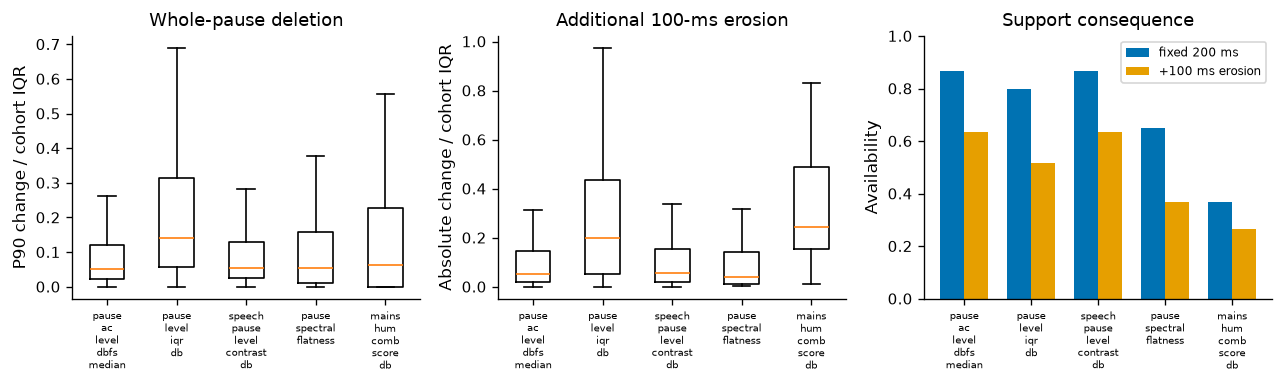

,layer,check,passed,observed,required,action_if_failed,blocking
0,reconstruction,all cohort raw estimands reconstruct,True,5709/5709,all,repair ledgers/aggregation,True
1,sensitivity,whole-pause deletion covers every eligible rec...,True,2440/2440,all pairs,repair clustered sensitivity accounting,True
2,sensitivity,population summaries use one row per recording...,True,2440,unique recording-feature rows,repair cluster weighting,True
3,boundary,fixed-guard additional-erosion audit completed,True,5/5 features; 0 errors,all features; 0 errors,repair erosion audit,True
4,boundary,availability transitions explicitly retained,True,reported,"[0,1] for every feature",repair missingness accounting,True


In [15]:
reconstruction_audit = pd.DataFrame()
cluster_deletion = pd.DataFrame()
cluster_summary = pd.DataFrame()
cluster_population_summary = pd.DataFrame()
boundary_sensitivity = pd.DataFrame()
boundary_population_summary = pd.DataFrame()

if RUN_COHORT_EXTRACTION and len(recording_table):
    reconstruction_rows = []
    deletion_rows = []
    for recording_id, stored in recording_table.set_index("logical_recording_id").iterrows():
        local_frames = frame_ledger.loc[frame_ledger["logical_recording_id"].eq(str(recording_id))]
        local_spectral = spectral_ledger.loc[spectral_ledger["logical_recording_id"].eq(str(recording_id))]
        local_extraction = type("LedgerBundle", (), {"frame_ledger": local_frames, "spectral_ledger": local_spectral, "recording": stored.to_dict()})()
        comparison = compare_reconstruction(local_extraction)
        comparison.insert(0, "logical_recording_id", recording_id)
        reconstruction_rows.append(comparison)
        local_deletion = cluster_delete_one_diagnostics(local_frames, local_spectral)
        if len(local_deletion):
            deletion_rows.append(local_deletion)
    reconstruction_audit = pd.concat(reconstruction_rows, ignore_index=True)
    cluster_deletion = (
        pd.concat(deletion_rows, ignore_index=True)
        if deletion_rows
        else pd.DataFrame()
    )
    cluster_summary = summarize_cluster_deletion(cluster_deletion)
    support_lookup = recording_table.set_index("logical_recording_id")[
        "qadd_pause_effective_nonfloor_support_sec"
    ]
    cluster_summary["pause_support_sec"] = cluster_summary[
        "logical_recording_id"
    ].map(support_lookup)

    scale_lookup = {}
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(recording_table[feature], errors="coerce").dropna()
        scale_lookup[feature] = (
            float(values.quantile(0.75) - values.quantile(0.25))
            if len(values)
            else np.nan
        )
    cluster_summary["cohort_iqr"] = cluster_summary["feature"].map(scale_lookup)
    cluster_summary["delete_one_p90_relative_to_cohort_iqr"] = (
        cluster_summary["delete_one_p90_absolute_change"]
        / cluster_summary["cohort_iqr"].replace(0, np.nan)
    )
    population_rows = []
    for feature, local in cluster_summary.groupby("feature", sort=False):
        finite = pd.to_numeric(
            local["delete_one_p90_absolute_change"], errors="coerce"
        ).dropna()
        relative = pd.to_numeric(
            local["delete_one_p90_relative_to_cohort_iqr"], errors="coerce"
        ).dropna()
        population_rows.append(
            {
                "feature": feature,
                "recording_count": int(len(finite)),
                "recording_level_p90_change_median": (
                    float(finite.median()) if len(finite) else np.nan
                ),
                "recording_level_p90_change_population_p90": (
                    float(finite.quantile(0.90)) if len(finite) else np.nan
                ),
                "relative_change_median": (
                    float(relative.median()) if len(relative) else np.nan
                ),
                "relative_change_population_p90": (
                    float(relative.quantile(0.90)) if len(relative) else np.nan
                ),
            }
        )
    cluster_population_summary = pd.DataFrame(population_rows)

    eligible_for_boundary = recording_table.loc[recording_table["qadd_pause_ac_level_dbfs_median_raw_estimate"].notna()].sort_values("qadd_pause_ac_level_dbfs_median_raw_estimate")
    if len(eligible_for_boundary) > MAX_BOUNDARY_RECORDINGS:
        positions = np.linspace(0, len(eligible_for_boundary) - 1, MAX_BOUNDARY_RECORDINGS).round().astype(int)
        eligible_for_boundary = eligible_for_boundary.iloc[np.unique(positions)]
    boundary_rows = []
    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    frozen_rows = frozen["recordings"].set_index("logical_recording_id")
    for recording_id in eligible_for_boundary["logical_recording_id"].astype(str):
        row = frozen_rows.loc[recording_id]
        try:
            views = decode_audio_views(media_path_for(row), ffmpeg=ffmpeg, ffprobe=ffprobe, analysis_rate=FS)
            primary = intervals_for(recording_id, frozen["primary_view"])
            strict_speech = intervals_for(recording_id, frozen["strict_speech_view"])
            strict_pause = intervals_for(recording_id, frozen["strict_pause_view"])
            reference_pauses = guarded_internal_pauses(
                primary,
                len(views.analysis_16k) / FS,
                strict_nonspeech=strict_pause,
                parameters=PARAMETERS,
            )
            eroded_pauses = erode_intervals(
                reference_pauses,
                len(views.analysis_16k) / FS,
                guard_ms=100.0,
                minimum_ms=PARAMETERS.minimum_residual_pause_ms,
            )
            reference = extract_qadd(
                views.analysis_16k, FS,
                primary_speech=primary,
                strict_speech=strict_speech,
                strict_internal_nonspeech=reference_pauses,
                pause_intervals_are_guarded=True,
                logical_recording_id=recording_id,
                parameters=PARAMETERS,
            ).recording
            eroded = extract_qadd(
                views.analysis_16k, FS,
                primary_speech=primary,
                strict_speech=strict_speech,
                strict_internal_nonspeech=eroded_pauses,
                pause_intervals_are_guarded=True,
                logical_recording_id=recording_id,
                parameters=PARAMETERS,
            ).recording
            for feature in ANALYSIS_FEATURES:
                raw_name = f"{feature}_raw_estimate"
                status_name = f"{feature}_status"
                reference_value = reference[raw_name]
                eroded_value = eroded[raw_name]
                boundary_rows.append(
                    {
                        "logical_recording_id": recording_id,
                        "feature": feature,
                        "condition": "additional_100ms_erosion",
                        "reference_guard_ms": PARAMETERS.pause_guard_ms,
                        "additional_erosion_ms_per_boundary": 100.0,
                        "reference_raw_estimate": reference_value,
                        "eroded_raw_estimate": eroded_value,
                        "absolute_change": (
                            abs(eroded_value - reference_value)
                            if np.isfinite(reference_value)
                            and np.isfinite(eroded_value)
                            else np.nan
                        ),
                        "reference_available": str(
                            reference[status_name]
                        ).startswith("ok_"),
                        "eroded_available": str(
                            eroded[status_name]
                        ).startswith("ok_"),
                        "availability_changed": str(
                            reference[status_name]
                        ).startswith("ok_")
                        != str(eroded[status_name]).startswith("ok_"),
                        "reference_pause_support_sec": reference[
                            "qadd_pause_effective_nonfloor_support_sec"
                        ],
                        "eroded_pause_support_sec": eroded[
                            "qadd_pause_effective_nonfloor_support_sec"
                        ],
                    }
                )
        except Exception as exc:
            boundary_rows.append(
                {
                    "logical_recording_id": recording_id,
                    "feature": pd.NA,
                    "condition": "error",
                    "error": str(exc),
                }
            )
    boundary_sensitivity = pd.DataFrame(boundary_rows)

    boundary_sensitivity["cohort_iqr"] = boundary_sensitivity[
        "feature"
    ].map(scale_lookup)
    boundary_sensitivity["absolute_change_relative_to_cohort_iqr"] = (
        boundary_sensitivity["absolute_change"]
        / boundary_sensitivity["cohort_iqr"].replace(0, np.nan)
    )
    boundary_population_summary = (
        boundary_sensitivity.groupby("feature", dropna=True)
        .agg(
            sampled_recordings=("logical_recording_id", "nunique"),
            paired_finite_count=("absolute_change", "count"),
            median_absolute_change=("absolute_change", "median"),
            p90_absolute_change=(
                "absolute_change",
                lambda values: values.dropna().quantile(0.90),
            ),
            median_relative_to_cohort_iqr=(
                "absolute_change_relative_to_cohort_iqr",
                "median",
            ),
            reference_availability=("reference_available", "mean"),
            eroded_availability=("eroded_available", "mean"),
            availability_transition_fraction=(
                "availability_changed",
                "mean",
            ),
        )
        .reset_index()
    )
    eligible_cluster_ids = set(
        frame_ledger.loc[frame_ledger["region"].eq("pause")]
        .groupby("logical_recording_id")["interval_index"]
        .nunique()
        .loc[lambda values: values.ge(2)]
        .index.astype(str)
    )
    observed_pairs = cluster_summary[
        ["logical_recording_id", "feature"]
    ].drop_duplicates()
    expected_pair_count = len(eligible_cluster_ids) * len(ANALYSIS_FEATURES)
    boundary_errors = boundary_sensitivity.get(
        "error", pd.Series(dtype=object)
    ).notna().sum()
    robustness_checks = validation_frame(
        [
            ValidationCheck("reconstruction", "all cohort raw estimands reconstruct", len(reconstruction_audit) > 0 and reconstruction_audit["pass"].all(), f"{int(reconstruction_audit['pass'].sum()) if len(reconstruction_audit) else 0}/{len(reconstruction_audit)}", "all", "repair ledgers/aggregation"),
            ValidationCheck("sensitivity", "whole-pause deletion covers every eligible recording-feature pair", len(observed_pairs) == expected_pair_count, f"{len(observed_pairs)}/{expected_pair_count}", "all pairs", "repair clustered sensitivity accounting"),
            ValidationCheck("sensitivity", "population summaries use one row per recording and feature", not cluster_summary[["logical_recording_id", "feature"]].duplicated().any(), str(len(cluster_summary)), "unique recording-feature rows", "repair cluster weighting"),
            ValidationCheck("boundary", "fixed-guard additional-erosion audit completed", len(boundary_population_summary) == len(ANALYSIS_FEATURES) and boundary_errors == 0, f"{len(boundary_population_summary)}/{len(ANALYSIS_FEATURES)} features; {boundary_errors} errors", "all features; 0 errors", "repair erosion audit"),
            ValidationCheck("boundary", "availability transitions explicitly retained", "availability_transition_fraction" in boundary_population_summary and boundary_population_summary["availability_transition_fraction"].between(0, 1).all(), "reported", "[0,1] for every feature", "repair missingness accounting"),
        ]
    )
    for frame, name in [
        (reconstruction_audit, "qadd_v4_1_reconstruction_audit"),
        (cluster_deletion, "qadd_v4_1_cluster_delete_one_long"),
        (cluster_summary, "qadd_v4_1_cluster_delete_one_by_recording"),
        (cluster_population_summary, "qadd_v4_1_cluster_delete_one_population"),
        (boundary_sensitivity, "qadd_v4_1_boundary_erosion_by_recording"),
        (boundary_population_summary, "qadd_v4_1_boundary_erosion_population"),
        (robustness_checks, "qadd_v4_1_robustness_checks"),
    ]:
        save_table_bundle(frame, TABLES, name)

    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.3))
    feature_labels = {
        feature: feature.replace("qadd_", "").replace("_", "\n")
        for feature in ANALYSIS_FEATURES
    }
    cluster_plot = [
        cluster_summary.loc[
            cluster_summary["feature"].eq(feature),
            "delete_one_p90_relative_to_cohort_iqr",
        ].dropna()
        for feature in ANALYSIS_FEATURES
    ]
    axes[0].boxplot(
        cluster_plot,
        showfliers=False,
    )
    axes[0].set_xticks(
        np.arange(1, len(ANALYSIS_FEATURES) + 1),
        labels=[feature_labels[f] for f in ANALYSIS_FEATURES],
    )
    axes[0].set(ylabel="P90 change / cohort IQR", title="Whole-pause deletion")
    axes[0].tick_params(axis="x", labelsize=6)
    erosion_plot = [
        boundary_sensitivity.loc[
            boundary_sensitivity["feature"].eq(feature),
            "absolute_change_relative_to_cohort_iqr",
        ].dropna()
        for feature in ANALYSIS_FEATURES
    ]
    axes[1].boxplot(
        erosion_plot,
        showfliers=False,
    )
    axes[1].set_xticks(
        np.arange(1, len(ANALYSIS_FEATURES) + 1),
        labels=[feature_labels[f] for f in ANALYSIS_FEATURES],
    )
    axes[1].set(ylabel="Absolute change / cohort IQR", title="Additional 100-ms erosion")
    axes[1].tick_params(axis="x", labelsize=6)
    positions = np.arange(len(ANALYSIS_FEATURES))
    population = boundary_population_summary.set_index("feature").reindex(ANALYSIS_FEATURES)
    axes[2].bar(positions - 0.18, population["reference_availability"], width=0.36, label="fixed 200 ms", color=OKABE_ITO["blue"])
    axes[2].bar(positions + 0.18, population["eroded_availability"], width=0.36, label="+100 ms erosion", color=OKABE_ITO["orange"])
    axes[2].set(xticks=positions, xticklabels=[feature_labels[f] for f in ANALYSIS_FEATURES], ylim=(0, 1), ylabel="Availability", title="Support consequence")
    axes[2].tick_params(axis="x", labelsize=6)
    axes[2].legend(fontsize=7)
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qadd_support_boundary_robustness",
        caption="QADD v4.1 clustered and boundary sensitivity. Whole-pause deletion is summarized once per recording; boundary sensitivity erodes the fixed 200-ms region by an additional 100 ms. Changes are scaled by the empirical cohort IQR only for cross-feature display; absolute-unit tables are retained. Availability is reported rather than treated as estimator error.",
        alt_text="Three panels show recording-level whole-pause deletion sensitivity across all five features, additional boundary-erosion sensitivity, and feature availability before and after erosion.",
    )
    plt.show()
else:
    robustness_checks = validation_frame(
        [ValidationCheck("robustness", "cohort reconstruction/support/boundary assessment", False, "NOT RUN", "completed", "run cohort extraction")]
    )
display(robustness_checks)


## 9. Empirical distributions, availability, and within-family structure

This section addresses feature behavior in the frozen cohort: distributions,
missingness/status, and redundancy. These results characterize the measurement
vector but do not establish correspondence with perception. Human-QC correspondence
belongs to the separate Goal 3 analysis and is intentionally absent here.


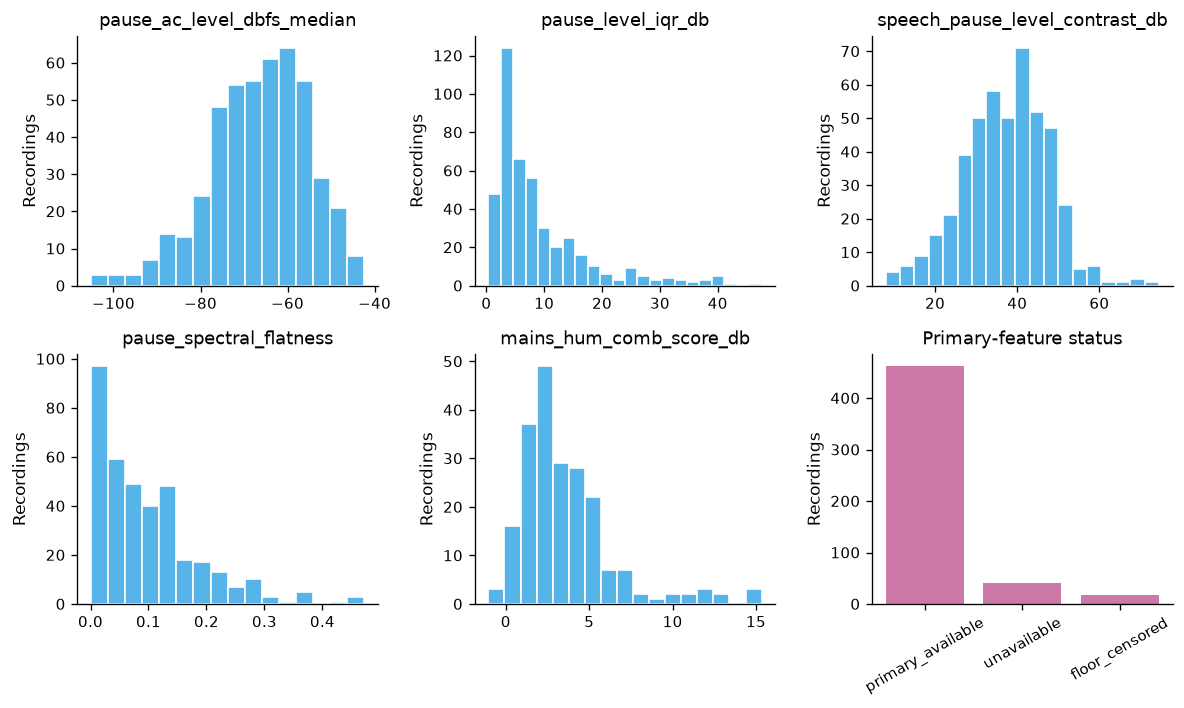

,feature,recording_count,available_count,available_fraction,median,q25,q75,status_counts_json
0,qadd_pause_ac_level_dbfs_median,519,462,0.890173,-65.504910,-73.684066,-58.299195,"{""floor_censored"": 17, ""insufficient_support"":..."
1,qadd_pause_level_iqr_db,519,440,0.847784,5.956983,3.522895,11.706668,"{""floor_censored"": 16, ""insufficient_support"":..."
2,qadd_speech_pause_level_contrast_db,519,462,0.890173,38.341430,30.596224,44.865086,"{""floor_censored"": 17, ""insufficient_support"":..."
3,qadd_pause_spectral_flatness,519,371,0.714836,0.080371,0.026657,0.139479,"{""insufficient_support"": 148, ""ok_high"": 191, ..."
4,qadd_mains_hum_comb_score_db,519,213,0.410405,2.821078,1.772040,4.668565,"{""insufficient_support"": 306, ""ok_high"": 97, ""..."


In [16]:
empirical_correlations = pd.DataFrame()
empirical_summary = pd.DataFrame()
if RUN_COHORT_EXTRACTION and len(recording_table):
    empirical_correlations = recording_table[list(ANALYSIS_FEATURES)].corr(method="spearman", min_periods=20)
    save_table_bundle(empirical_correlations.reset_index(), TABLES, "qadd_v4_1_spearman_feature_correlations")
    summary_rows = []
    for feature in ANALYSIS_FEATURES:
        values = pd.to_numeric(recording_table[feature], errors="coerce")
        finite = values[np.isfinite(values)]
        status_column = f"{feature}_status"
        summary_rows.append(
            {
                "feature": feature,
                "recording_count": len(recording_table),
                "available_count": len(finite),
                "available_fraction": len(finite) / len(recording_table),
                "median": float(finite.median()) if len(finite) else np.nan,
                "q25": float(finite.quantile(0.25)) if len(finite) else np.nan,
                "q75": float(finite.quantile(0.75)) if len(finite) else np.nan,
                "status_counts_json": json.dumps(
                    recording_table[status_column].value_counts(dropna=False).to_dict(),
                    sort_keys=True,
                ),
            }
        )
    empirical_summary = pd.DataFrame(summary_rows)
    save_table_bundle(empirical_summary, TABLES, "qadd_v4_1_empirical_summary")

    fig, axes = plt.subplots(2, 3, figsize=(10.0, 6.0))
    for ax, feature in zip(axes.flat, ANALYSIS_FEATURES):
        values = recording_table[feature].dropna()
        ax.hist(values, bins="fd" if len(values) > 1 else 1, color=OKABE_ITO["sky"], edgecolor="white")
        ax.set(title=feature.replace("qadd_", ""), ylabel="Recordings")
    status_counts = recording_table["qadd_family_status"].value_counts()
    axes.flat[-1].bar(status_counts.index, status_counts.values, color=OKABE_ITO["purple"])
    axes.flat[-1].tick_params(axis="x", rotation=30)
    axes.flat[-1].set(title="Primary-feature status", ylabel="Recordings")
    fig.tight_layout()
    save_publication_figure(
        fig, FIGURES, "figure_qadd_empirical_distributions",
        caption="Empirical QADD v4.1 feature distributions and primary-feature availability in the frozen cohort.",
        alt_text="Histograms show the five prespecified QADD measures; a final bar chart shows primary-feature status counts.",
    )
    plt.show()
    empirical_checks = validation_frame(
        [
            ValidationCheck(
                "empirical",
                "one empirical summary row per analysis feature",
                len(empirical_summary) == len(ANALYSIS_FEATURES),
                str(len(empirical_summary)),
                str(len(ANALYSIS_FEATURES)),
                "repair empirical summary",
            ),
            ValidationCheck(
                "empirical",
                "feature availability explicitly reported",
                empirical_summary["available_fraction"].between(0, 1).all(),
                "checked",
                "[0,1]",
                "repair availability accounting",
            ),
        ]
    )
else:
    empirical_checks = validation_frame(
        [ValidationCheck("empirical", "cohort distributions and structure", False, "NOT RUN", "completed", "run cohort extraction")]
    )
display(empirical_summary if len(empirical_summary) else empirical_checks)


## 10. Reviewer-facing recording gallery

Gallery selection is algorithmic and label-blind: primary-feature quantiles, support
extremes, floor-censoring extremes, flatness extremes, and strongest targeted hum.
Each panel retains time position and interval identity so reviewers can audit what the
estimators measured. The gallery supports review; it is not a threshold-tuning set.


In [17]:
gallery_index = pd.DataFrame()


def choose_gallery(table: pd.DataFrame) -> pd.DataFrame:
    candidates = []
    eligible = table.loc[table["qadd_pause_ac_level_dbfs_median_raw_estimate"].notna()].copy()
    for quantile in [0.05, 0.25, 0.50, 0.75, 0.95]:
        target = eligible["qadd_pause_ac_level_dbfs_median_raw_estimate"].quantile(quantile)
        index = (eligible["qadd_pause_ac_level_dbfs_median_raw_estimate"] - target).abs().idxmin()
        candidates.append((eligible.loc[index, "logical_recording_id"], f"primary_q{int(quantile*100):02d}"))
    extrema = [
        ("qadd_pause_at_floor_frame_fraction", "max", "highest_floor_fraction"),
        ("qadd_pause_effective_nonfloor_support_sec", "min", "lowest_nonfloor_support"),
        ("qadd_pause_spectral_flatness_raw_estimate", "min", "lowest_flatness"),
        ("qadd_pause_spectral_flatness_raw_estimate", "max", "highest_flatness"),
        ("qadd_mains_hum_comb_score_db_raw_estimate", "max", "highest_hum_comb"),
    ]
    for column, operation, reason in extrema:
        local = table.loc[table[column].notna()]
        if len(local):
            index = local[column].idxmax() if operation == "max" else local[column].idxmin()
            candidates.append((local.loc[index, "logical_recording_id"], reason))
    frame = pd.DataFrame(candidates, columns=["logical_recording_id", "selection_reason"])
    return frame.groupby("logical_recording_id", as_index=False)["selection_reason"].agg(";".join)


def plot_gallery_recording(recording_id: str, reason: str):
    row = frozen["recordings"].set_index("logical_recording_id").loc[str(recording_id)]
    views = decode_audio_views(media_path_for(row), ffmpeg=shutil.which("ffmpeg"), ffprobe=shutil.which("ffprobe"), analysis_rate=FS)
    primary = intervals_for(recording_id, frozen["primary_view"])
    strict_speech = intervals_for(recording_id, frozen["strict_speech_view"])
    strict_pause = intervals_for(recording_id, frozen["strict_pause_view"])
    extraction = extract_qadd(
        views.analysis_16k, FS, primary_speech=primary, strict_speech=strict_speech,
        strict_internal_nonspeech=strict_pause, logical_recording_id=recording_id,
    )
    time = np.arange(len(views.analysis_16k)) / FS
    stride = max(1, len(time) // 12000)
    fig, axes = plt.subplots(3, 1, figsize=(10.0, 6.7), sharex=True)
    axes[0].plot(time[::stride], views.analysis_16k[::stride], color=OKABE_ITO["grey"], linewidth=0.5)
    for interval in primary:
        axes[0].axvspan(interval.start_sec, interval.end_sec, color=OKABE_ITO["sky"], alpha=0.18)
    pauses = guarded_internal_pauses(primary, len(time) / FS, strict_nonspeech=strict_pause, parameters=PARAMETERS)
    for interval in pauses:
        axes[0].axvspan(interval.start_sec, interval.end_sec, color=OKABE_ITO["orange"], alpha=0.28)
    axes[0].set(ylabel="Amplitude", title=f"{recording_id} — {reason}")

    frame = extraction.frame_ledger
    for region, color in [("speech", OKABE_ITO["blue"]), ("pause", OKABE_ITO["orange"])]:
        local = frame.loc[frame["region"].eq(region)]
        axes[1].scatter((local["frame_start_sec"] + local["frame_end_sec"]) / 2, local["rms_dbfs"], s=5, alpha=0.5, color=color, label=region)
    axes[1].axhline(PARAMETERS.dbfs_floor_db, color=OKABE_ITO["black"], linestyle=":", linewidth=1)
    axes[1].set(ylabel="30-ms AC level (dBFS)")
    axes[1].legend(loc="best")

    spectral = extraction.spectral_ledger
    flat = spectral.loc[
        spectral["window_kind"].eq("flatness")
        & pd.to_numeric(spectral["spectral_flatness"], errors="coerce").notna()
    ]
    hum = spectral.loc[
        spectral["window_kind"].eq("hum")
        & pd.to_numeric(spectral["hum_score_max_db"], errors="coerce").notna()
    ]
    if len(flat):
        axes[2].scatter((flat["window_start_sec"] + flat["window_end_sec"]) / 2, flat["spectral_flatness"], s=12, color=OKABE_ITO["green"], label="flatness")
    else:
        axes[2].text(
            0.02,
            0.88,
            f"Flatness unavailable: {extraction.recording['qadd_pause_spectral_flatness_status']}",
            transform=axes[2].transAxes,
            color=OKABE_ITO["green"],
            fontsize=8,
        )
    axes[2].set(xlabel="Recording time (s)", ylabel="Spectral flatness", ylim=(0, 1))
    if len(hum):
        hum_axis = axes[2].twinx()
        hum_axis.scatter((hum["window_start_sec"] + hum["window_end_sec"]) / 2, hum["hum_score_max_db"], s=12, color=OKABE_ITO["vermillion"], label="hum comb")
        hum_axis.set_ylabel("Hum comb score (dB)")
    else:
        axes[2].text(
            0.02,
            0.75,
            f"Hum unavailable: {extraction.recording['qadd_mains_hum_comb_score_db_status']}",
            transform=axes[2].transAxes,
            color=OKABE_ITO["vermillion"],
            fontsize=8,
        )
    fig.tight_layout()
    save_publication_figure(
        fig, GALLERY, f"qadd_gallery_{recording_id}",
        caption=f"Label-blind QADD audit gallery: {recording_id}; selection={reason}. Blue spans are frozen primary speech and orange spans are guarded strict pauses.",
        alt_text="Waveform with frozen speech and pause regions, frame AC levels over time, and pause spectral flatness and hum-comb window values.",
        dpi=300,
    )
    plt.close(fig)


if BUILD_GALLERY and RUN_COHORT_EXTRACTION and len(recording_table):
    gallery_index = choose_gallery(recording_table)
    for row in gallery_index.itertuples(index=False):
        try:
            plot_gallery_recording(str(row.logical_recording_id), str(row.selection_reason))
        except Exception as exc:
            gallery_index.loc[gallery_index["logical_recording_id"].eq(row.logical_recording_id), "gallery_error"] = str(exc)
    save_table_bundle(gallery_index, GALLERY, "qadd_gallery_index")
else:
    gallery_index = pd.DataFrame([{"logical_recording_id": pd.NA, "selection_reason": "NOT RUN"}])
display(gallery_index)


,logical_recording_id,selection_reason
0,CAPT0000025_272_1_20230130_240_PSG_BAMBOO,lowest_nonfloor_support
1,CAPT0000119_272_1_20240703_240_PSG_BAMBOO,primary_q95
2,CAPT0000131_272_1_20241024_240_PSG_BAMBOO,primary_q50
3,CNEC018_1045_1_20250702_240_PSG_BAMBOO,highest_floor_fraction
4,CNEC025_1045_1_20260404_240_PSG_BAMBOO,primary_q05
5,MIBD37_270_2_20231201_240_PSG_BAMBOO,lowest_flatness
6,TIBD118_270_1_20250212_240_PSG_BAMBOO,primary_q75
7,TIBD120_1003_1_20250526_240_PSG_BAMBOO,highest_flatness
8,TIBD66_1003_1_20230104_240_PSG_BAMBOO,highest_hum_comb
9,TIBD85_1003_1_20231016_240_PSG_BAMBOO,primary_q25


## 11. Gates and candidate freeze

“Code ran” is not a scientific gate. A publication freeze requires independent
evidence for technical correctness, synthetic/measurement-science validity,
cohort robustness, empirical behavior, and documented scientific review. Human-QC
correspondence is a downstream Goal 3 analysis and cannot block feature extraction.


In [18]:
if RUN_PACKAGE_TESTS:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_qadd_v4.py", "-q"],
        cwd=ROOT,
        capture_output=True,
        text=True,
    )
    package_test_passed = completed.returncode == 0
    package_test_observed = (completed.stdout + "\n" + completed.stderr).strip()[-1000:]
else:
    package_test_passed = bool(PACKAGE_TESTS_CONFIRMED)
    package_test_observed = (
        "confirmed from external repository test run"
        if PACKAGE_TESTS_CONFIRMED
        else "NOT RUN — execute: python -m pytest tests/test_qadd_v4.py -q"
    )

review_passed = (
    QADD_REVIEW_DECISION == "ACCEPT_QADD_V4_1"
    and bool(QADD_REVIEWER.strip())
    and bool(QADD_REVIEW_RATIONALE.strip())
    and len(gallery_index)
    and not gallery_index.get("gallery_error", pd.Series(dtype=object)).notna().any()
)

layer_summary = validation_frame(
    [
        ValidationCheck("technical", "package tests", package_test_passed, package_test_observed, "all pass", "repair implementation/tests"),
        ValidationCheck("technical", "formula/reconstruction controls", gate_passed(formula_checks), f"{int(formula_checks['passed'].sum())}/{len(formula_checks)}", "all blocking checks pass", "repair implementation"),
        ValidationCheck("input", "frozen input contract", gate_passed(input_checks), f"{int(input_checks['passed'].sum())}/{len(input_checks)}", "all pass", "repair frozen inputs"),
        ValidationCheck("extraction", "cohort extraction contract", gate_passed(extraction_checks), f"{int(extraction_checks['passed'].sum())}/{len(extraction_checks)}", "all pass", "resolve extraction"),
        ValidationCheck("scientific", "mechanism/discriminant controls", gate_passed(mechanism_checks), f"{int(mechanism_checks['passed'].sum())}/{len(mechanism_checks)}", "all pass", "revise estimator/claims"),
        ValidationCheck("scientific", "floor-censoring calibration", gate_passed(floor_checks), f"{int(floor_checks['passed'].sum())}/{len(floor_checks)}", "all pass", "lower ceiling or revise estimator"),
        ValidationCheck("scientific", "codec robustness", gate_passed(codec_checks), f"{int(codec_checks['passed'].sum())}/{len(codec_checks)}", "all pass", "stratify/qualify codec dependence"),
        ValidationCheck("scientific", "clustered and boundary sensitivity accounting", gate_passed(robustness_checks), f"{int(robustness_checks['passed'].sum())}/{len(robustness_checks)}", "all pass", "repair sensitivity design/accounting"),
        ValidationCheck("empirical", "cohort distributions and availability", gate_passed(empirical_checks), f"{int(empirical_checks['passed'].sum())}/{len(empirical_checks)}", "all pass", "complete cohort characterization"),
        ValidationCheck("review", "gallery reviewed and accepted", review_passed, QADD_REVIEW_DECISION, "ACCEPT_QADD_V4_1 with reviewer/rationale", "complete scientific review"),
        ValidationCheck("integration", "central registry/CLI approved", PACKAGE_INTEGRATION_APPROVED, str(PACKAGE_INTEGRATION_APPROVED), "True after measurement freeze", "integrate frozen features downstream", blocking=False),
    ]
)
save_table_bundle(layer_summary, TABLES, "qadd_v4_1_gate_summary")
display(layer_summary)

all_blocking_layers_pass = gate_passed(layer_summary)
freeze_requested_safely = (
    PUBLISH_AND_FREEZE_QADD_V4_1 and all_blocking_layers_pass
)
manifest = {
    "measurement_version": MEASUREMENT_VERSION,
    "candidate_only": not freeze_requested_safely,
    "all_blocking_layers_pass": all_blocking_layers_pass,
    "publish_and_freeze_requested": PUBLISH_AND_FREEZE_QADD_V4_1,
    "analysis_features": list(ANALYSIS_FEATURES),
    "parameters": PARAMETERS.to_dict(),
    "implementation_sha256": sha256_file(ROOT / "src/paper1_qc/qadd.py"),
    "gate_table_sha256": sha256_file(TABLES / "qadd_v4_1_gate_summary.csv"),
    "review": {
        "decision": QADD_REVIEW_DECISION,
        "reviewer": QADD_REVIEWER,
        "rationale": QADD_REVIEW_RATIONALE,
    },
}
if PUBLISH_AND_FREEZE_QADD_V4_1 and not all_blocking_layers_pass:
    raise RuntimeError("QADD freeze requested, but one or more blocking validation layers failed.")
if freeze_requested_safely:
    manifest["stage_file_sha256"] = {
        str(path.relative_to(STAGE)): sha256_file(path)
        for path in sorted(STAGE.rglob("*"))
        if path.is_file()
        and path.name not in {
            "qadd_v4_1_candidate_manifest.json",
            "qadd_v4_1_frozen_manifest.json",
        }
    }
    write_json(manifest, AUDIT / "qadd_v4_1_frozen_manifest.json")
    frozen_root = (
        MAIN_OUTPUTS
        / "02_FEATURE_FREEZE"
        / "additive_interference"
        / MEASUREMENT_VERSION
    )
    temporary_frozen_root = frozen_root.with_name(
        f".{frozen_root.name}.copying"
    )
    if frozen_root.exists() or temporary_frozen_root.exists():
        raise FileExistsError(
            f"Refusing to overwrite an existing QADD freeze: {frozen_root}"
        )
    frozen_root.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(STAGE, temporary_frozen_root)
    temporary_frozen_root.replace(frozen_root)
    display(
        Markdown(
            f"## FROZEN — QADD v4.1 passed every blocking layer\n\n"
            f"Immutable snapshot: `{frozen_root}`"
        )
    )
else:
    write_json(manifest, AUDIT / "qadd_v4_1_candidate_manifest.json")
    display(Markdown("## CANDIDATE ONLY — inspect the gate table; publication/freeze is blocked"))


,layer,check,passed,observed,required,action_if_failed,blocking
0,technical,package tests,True,[32m.[0m[32m.[0m[32m.[0m[32m.[0m[32m....,all pass,repair implementation/tests,True
1,technical,formula/reconstruction controls,True,6/6,all blocking checks pass,repair implementation,True
2,input,frozen input contract,True,5/5,all pass,repair frozen inputs,True
3,extraction,cohort extraction contract,True,4/4,all pass,resolve extraction,True
4,scientific,mechanism/discriminant controls,True,10/10,all pass,revise estimator/claims,True
5,scientific,floor-censoring calibration,True,3/3,all pass,lower ceiling or revise estimator,True
6,scientific,codec robustness,True,4/4,all pass,stratify/qualify codec dependence,True
7,scientific,clustered and boundary sensitivity accounting,True,5/5,all pass,repair sensitivity design/accounting,True
8,empirical,cohort distributions and availability,True,2/2,all pass,complete cohort characterization,True
9,review,gallery reviewed and accepted,True,ACCEPT_QADD_V4_1,ACCEPT_QADD_V4_1 with reviewer/rationale,complete scientific review,True


## FROZEN — QADD v4.1 passed every blocking layer

Immutable snapshot: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FREEZE\additive_interference\qadd-v4.1.0`

In [19]:
# Copy only main tables in the folder

# Export the frozen QADD recording-level feature table to MAIN outputs
# Run only after the QADD freeze cell completes successfully.

CENTRAL_FEATURE_TABLES = MAIN_OUTPUTS / "02_FEATURE_TABLES"

QADD_FROZEN_ROOT = (
    MAIN_OUTPUTS
    / "02_FEATURE_FREEZE"
    / "additive_interference"
    / MEASUREMENT_VERSION
)

FROZEN_MANIFEST = (
    QADD_FROZEN_ROOT
    / "audit"
    / "qadd_v4_1_frozen_manifest.json"
)

SOURCE_TABLES = QADD_FROZEN_ROOT / "tables"

REQUIRED_FEATURES = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
    "qadd_pause_spectral_flatness",
    "qadd_mains_hum_comb_score_db",
]

SOURCE_FILES = [
    SOURCE_TABLES / "qadd_v4_1_recording_features.csv",
    SOURCE_TABLES / "qadd_v4_1_recording_features.parquet",
]


# ------------------------------------------------------------------
# 1. Confirm that this is a formally frozen feature family
# ------------------------------------------------------------------

if not FROZEN_MANIFEST.exists():
    raise RuntimeError(
        "QADD is not formally frozen. The frozen manifest was not found:\n"
        f"{FROZEN_MANIFEST}\n\n"
        "Complete the scientific review and freeze cell before exporting "
        "the main feature table."
    )

missing_sources = [path for path in SOURCE_FILES if not path.exists()]

if missing_sources:
    raise FileNotFoundError(
        "The frozen QADD feature-table bundle is incomplete:\n"
        + "\n".join(str(path) for path in missing_sources)
    )


# ------------------------------------------------------------------
# 2. Validate the recording-level table before copying
# ------------------------------------------------------------------

qadd_csv = pd.read_csv(SOURCE_FILES[0])
qadd_parquet = pd.read_parquet(SOURCE_FILES[1])

required_columns = ["logical_recording_id", *REQUIRED_FEATURES]

missing_columns = [
    column for column in required_columns
    if column not in qadd_csv.columns
]

if missing_columns:
    raise ValueError(
        "The frozen QADD table is missing required columns:\n"
        + "\n".join(missing_columns)
    )

if qadd_csv["logical_recording_id"].isna().any():
    raise ValueError("The QADD table contains missing recording identifiers.")

if qadd_csv["logical_recording_id"].astype(str).duplicated().any():
    duplicates = (
        qadd_csv.loc[
            qadd_csv["logical_recording_id"].astype(str).duplicated(False),
            "logical_recording_id",
        ]
        .astype(str)
        .tolist()
    )
    raise ValueError(
        "The QADD table contains duplicate recording identifiers:\n"
        + "\n".join(duplicates[:20])
    )

csv_ids = set(qadd_csv["logical_recording_id"].astype(str))
parquet_ids = set(qadd_parquet["logical_recording_id"].astype(str))

if csv_ids != parquet_ids:
    raise ValueError(
        "The frozen CSV and Parquet tables do not contain the same recordings."
    )

if len(qadd_csv) != len(qadd_parquet):
    raise ValueError(
        "The frozen CSV and Parquet tables have different row counts."
    )


# ------------------------------------------------------------------
# 3. Copy into the central feature-table folder
# ------------------------------------------------------------------

CENTRAL_FEATURE_TABLES.mkdir(parents=True, exist_ok=True)

exported_files = []

for source in SOURCE_FILES:
    destination = CENTRAL_FEATURE_TABLES / source.name
    source_hash = sha256_file(source)

    if destination.exists():
        destination_hash = sha256_file(destination)

        if destination_hash != source_hash:
            raise FileExistsError(
                "A different file already exists at the central destination.\n"
                "Refusing to overwrite it because this would compromise "
                "feature-version traceability:\n"
                f"{destination}"
            )

        action = "already present and identical"

    else:
        shutil.copy2(source, destination)

        if sha256_file(destination) != source_hash:
            raise RuntimeError(
                f"Hash verification failed after copying:\n{destination}"
            )

        action = "copied and hash-verified"

    exported_files.append(
        {
            "file": destination.name,
            "action": action,
            "rows": len(qadd_csv),
            "columns": len(qadd_csv.columns),
            "sha256": source_hash,
        }
    )


# ------------------------------------------------------------------
# 4. Report the completed export
# ------------------------------------------------------------------

export_summary = pd.DataFrame(exported_files)

display(
    Markdown(
        "## QADD central feature-table export complete\n\n"
        f"Destination: `{CENTRAL_FEATURE_TABLES}`\n\n"
        f"Recordings: **{len(qadd_csv):,}**  \n"
        f"Columns: **{len(qadd_csv.columns)}**  \n"
        f"Final QADD features: **{len(REQUIRED_FEATURES)}**"
    )
)

display(export_summary)
display(
    qadd_csv[
        [
            "logical_recording_id",
            *REQUIRED_FEATURES,
            "qadd_primary_analysis_eligible",
            "qadd_family_status",
        ]
    ].head()
)

## QADD central feature-table export complete

Destination: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_TABLES`

Recordings: **519**  
Columns: **64**  
Final QADD features: **5**

,file,action,rows,columns,sha256
0,qadd_v4_1_recording_features.csv,copied and hash-verified,519,64,9ef67d749a4e0c32dbacd45b11e5172c46a0d795f10e79...
1,qadd_v4_1_recording_features.parquet,copied and hash-verified,519,64,218b1b087b75adfcdc250e4428ffaea77dd2a3ede95c9b...


,logical_recording_id,qadd_pause_ac_level_dbfs_median,qadd_pause_level_iqr_db,qadd_speech_pause_level_contrast_db,qadd_pause_spectral_flatness,qadd_mains_hum_comb_score_db,qadd_primary_analysis_eligible,qadd_family_status
0,C02_1075_1_20260420_240_PSG_BAMBOO,-62.136878,4.280642,34.768722,0.005448,NaN,True,primary_available
1,C02_1075_2_20260421_240_PSG_BAMBOO,-61.809081,4.976389,36.827114,0.006121,5.529400,True,primary_available
2,C03_1075_1_20260412_240_PSG_BAMBOO,-80.987449,7.433013,56.065650,0.140603,1.272517,True,primary_available
3,C03_1075_2_20260423_240_PSG_BAMBOO,-78.354950,7.641896,50.421201,0.088080,NaN,True,primary_available
4,C04_1075_1_20260419_240_PSG_BAMBOO,-84.262525,14.830724,41.369402,0.280958,NaN,True,primary_available
